# Project: Optimisation of a bank’s marketing campaign

# Introduction and Problem Statement

Project objective: To build a machine learning model capable of predicting whether a customer will open a term deposit (target variable y).
Business value: To reduce marketing communication costs by focusing on the most loyal customers and improving the efficiency of the call centre.

Quality metrics: The primary metrics selected are ROC-AUC and F1-score. As we have a significant class imbalance (~11% positive reviews), standard accuracy is not a meaningful measure. The F1-score will allow us to strike a balance between precision and recall.

# Importing libraries and configuration

In [1]:
# Configuring automatic module reloading during development
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings

# Suppressing unnecessary warnings for a more compact output during training/experiments.
os.environ["PYTHONWARNINGS"] = "ignore"

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    warnings.filterwarnings("ignore", category=UserWarning, module="pkg_resources")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb

# Models and pre-processing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import uniform, randint

# Boosting and optimisation
from lightgbm import LGBMClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# Adding the project root to sys.path for importing custom modules from the src folder
PROJECT_ROOT = os.path.abspath(os.path.join(".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Importing helper functions for model evaluation and data preparation
from src.utils import (  # noqa: E402
    evaluate_model,
    plot_train_test_matrix,
    plot_feature_importance,
    plot_curves,
    find_best_threshold,
    get_metrix,
)


pd.set_option("display.max_columns", None)

# 1. Data loading and exploratory data analysis (EDA)

In [2]:
# Loading the initial dataset for EDA and subsequent data preparation, and checking the dataset’s dimensions
bank_df = pd.read_csv("../data/bank-additional-full.csv", sep=";")
print(f"Dataset size: {bank_df.shape}")

Dataset size: (41188, 21)


## 1.1. Analysis of the target variable
First of all, let’s check the class balance:

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


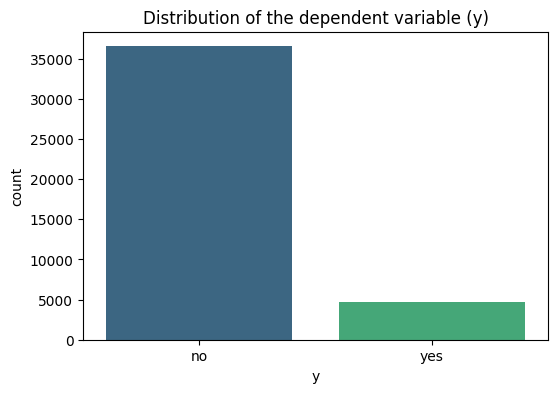

In [3]:
# We assess the imbalance in the target class in order to select the appropriate metrics and training strategy.
target_counts = bank_df["y"].value_counts(normalize=True)
print(target_counts)

# Visually checking the class distribution before building models.
plt.figure(figsize=(6, 4))
sns.countplot(x="y", data=bank_df, palette="viridis")
plt.title("Distribution of the dependent variable (y)")
plt.show()

Conclusion: There is a significant class imbalance (88.7% ‘no’ versus 11.3% ‘yes’). This means that when training the model, we cannot use the Accuracy metric, as it would ignore the minority class. We need to focus on the F1-score or Recall.

## 1.2. Statistical analysis of numerical characteristics

In [4]:
# A quick overview of basic statistics for numerical variables:
bank_df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


Observations:

Age: The average age of the customer is 40. The minimum is 17, and the maximum is 98.

Duration: Call duration has a large standard deviation (259 sec). It is important to remember that this parameter is not known until the call takes place, so it should be used with caution in actual forecasting.

Pdays: A value of 999 indicates that the customer has not been contacted before. This attribute requires transformation.

## 1.3. Analysis of categorical characteristics

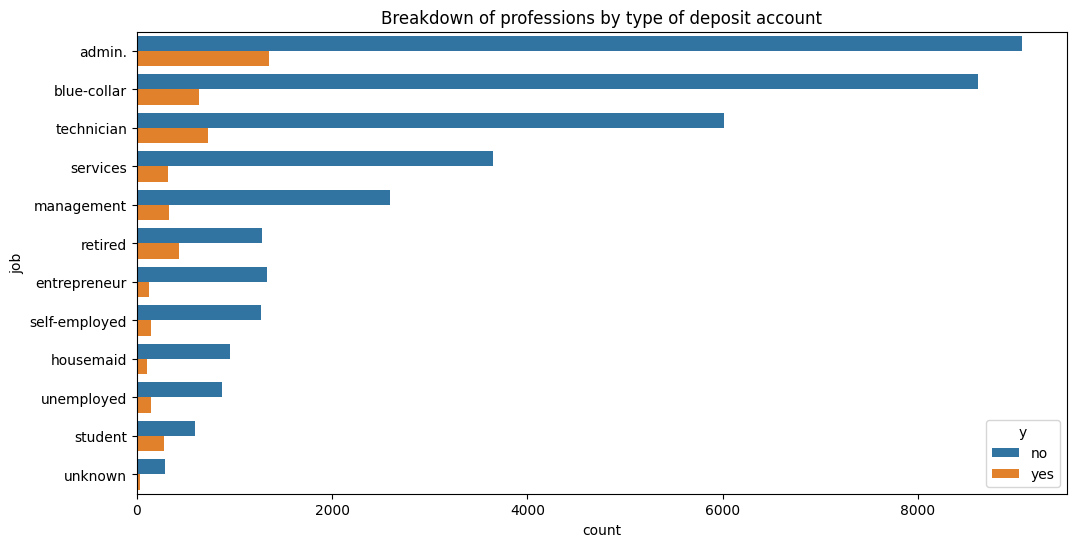

In [5]:
# Visualization: shows the distribution of professions by response to the deposit offer — to identify groups with high/low conversion rates
plt.figure(figsize=(12, 6))
sns.countplot(y="job", hue="y", data=bank_df, order=bank_df["job"].value_counts().index)
plt.title("Breakdown of professions by type of deposit account")
plt.show()

Hypothesis 1: Retired customers and students have a higher conversion rate compared to the blue-collar category

The breakdown by profession confirms the imbalance: although the highest number of successful contacts is in the ‘admin.’ category, the ‘yes’/‘no’ ratio is visibly higher in the ‘student’ and ‘retired’ categories. The most difficult category to engage is ‘blue-collar’, where the vast majority of contacts result in a rejection

## 1.4. Analysis of previous contact experiences (post-outcome)

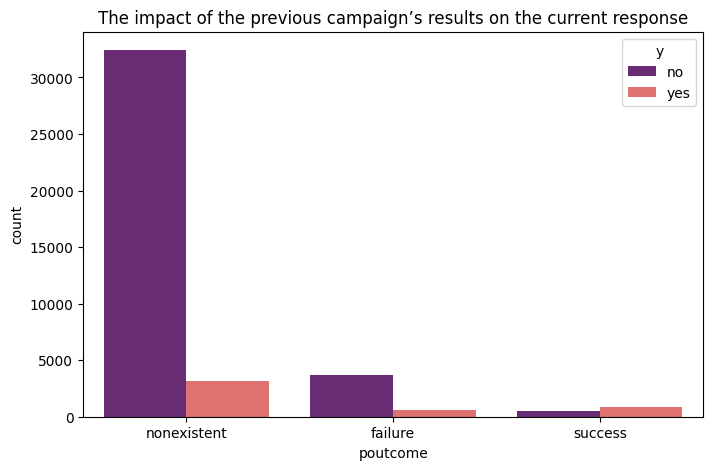

In [6]:
# Visualising the impact of the previous campaign’s results on the current response.
plt.figure(figsize=(8, 5))
sns.countplot(x="poutcome", hue="y", data=bank_df, palette="magma")
plt.title("The impact of the previous campaign’s results on the current response")
plt.show()

The visualisation of the results from the previous campaign allows us to draw some crucial conclusions:

‘Success’ category: This is the only group where the number of positive responses (‘yes’) EXCEEDS the number of refusals. If a customer has opened a deposit account before, the likelihood of success on a repeat occasion is highest.

‘Nonexistent’ category: The largest group. Most customers are new to the bank in the context of this service, which creates significant noise for the model.

Failure category: Even if the previous contact was unsuccessful, the chances of success now appear higher than for new customers (nonexistent), which highlights the importance of ‘warming up’ the customer base.

Hypothesis 2: The ‘outcome’ feature will be one of the most influential when building boosting models, as it has the strongest discriminatory power.

The data show that previous successful experience (‘success’) is the most powerful predictor: in this group, the number of acceptances exceeds the number of rejections.

## 1.5. Analysis of the conversion of categorical features

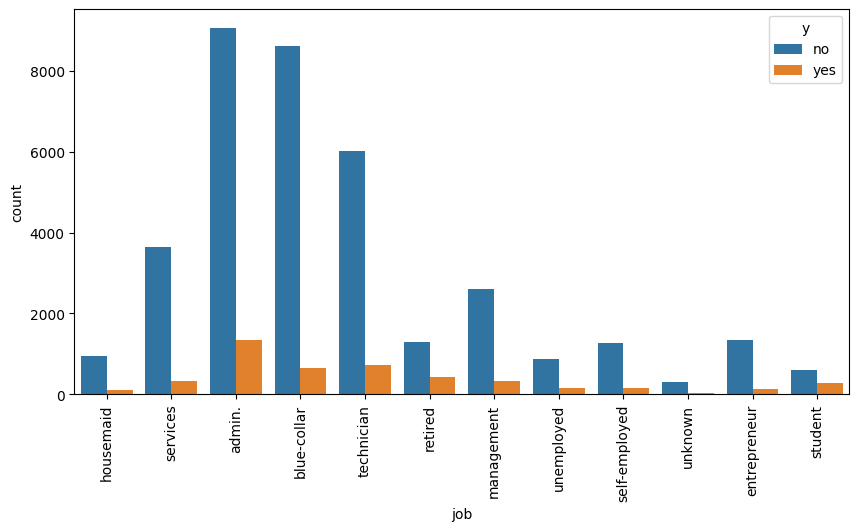

In [7]:
# Visualisation of the distribution of clients by profession and comparison of responses
plt.figure(figsize=(10, 5))
sns.countplot(bank_df, x="job", hue="y")
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='job'>

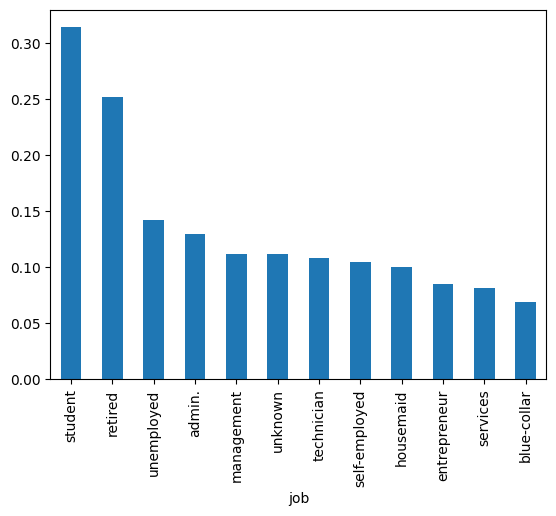

In [8]:
# Calculating the relative conversion rate for each profession and creating a graph to visualise the results.
job_conversion = (
    bank_df.groupby("job")["y"]
    .value_counts(normalize=True)
    .unstack()["yes"]
    .sort_values(ascending=False)
)
job_conversion.plot(kind="bar")

Although administrators lead in terms of absolute numbers, an analysis of relative conversion rates paints a different picture:
Students (~31%) and pensioners (~25%) are the most likely to open a savings account.
This confirms that the model should focus not on the size of the segment, but on its specific characteristics (young people and the elderly are more likely to seek savings instruments).

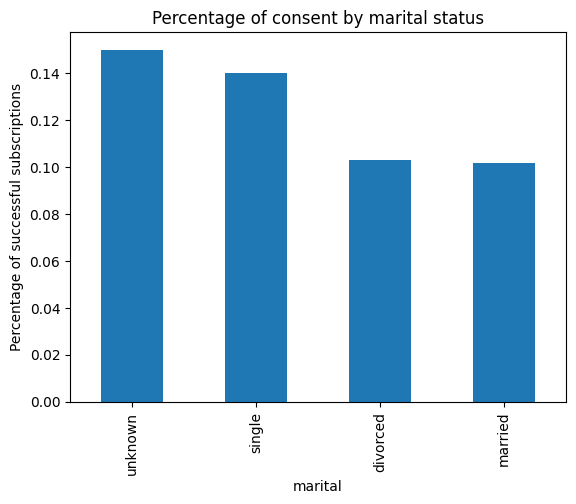

In [9]:
# Calculate the relative conversion rate (the proportion of 'yes' responses) for each value of 'marital'.
marital_conversion = (
    bank_df.groupby("marital")["y"]
    .value_counts(normalize=True)
    .unstack()["yes"]
    .sort_values(ascending=False)
)
marital_conversion.plot(kind="bar")
plt.title("Percentage of consent by marital status")
plt.ylabel("Percentage of successful subscriptions")
plt.show()

Customers with 'single' status show a higher propensity to convert compared to those who are married or divorced.
Interesting insight: the 'unknown' category has the highest consent rate. This may indicate that customers who provide less personal data may have a distinct behavioural profile.
Hypothesis 3: The marital status 'single' and the occupations 'student'/'retired' will be strong positive predictors for the model.

## 1.6. Analysis of the pdays attribute and creation of was_contacted

In [10]:
# Convert 'pdays' to a binary flag 'was_contacted':
# 1 — the client has already been contacted, 0 — new (pdays == 999).
# This removes the special value 999 and gives the model a clearer signal about previous contact.
bank_df["was_contacted"] = bank_df["pdays"].apply(lambda x: 1 if x != 999 else 0)

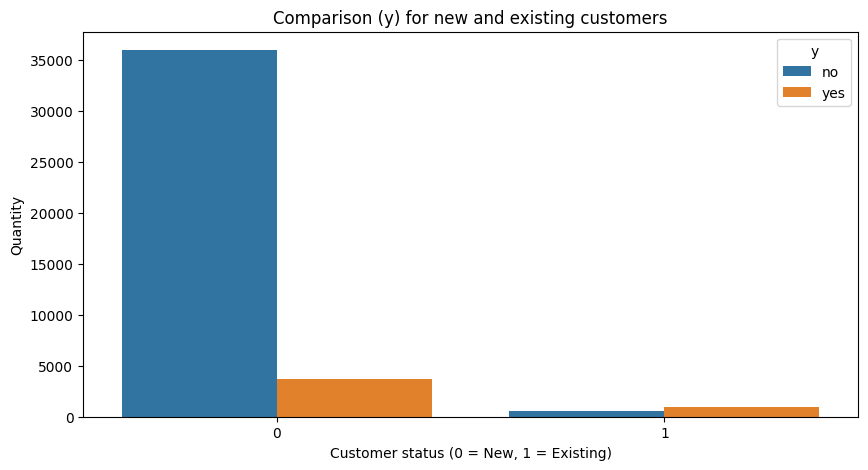

In [11]:
# Comparison of the target variable distribution for new and previously contacted clients
plt.figure(figsize=(10, 5))
sns.countplot(bank_df, x="was_contacted", hue="y")
plt.title("Comparison (y) for new and existing customers")
plt.xlabel("Customer status (0 = New, 1 = Existing)")
plt.ylabel("Quantity")
plt.show()

<Axes: xlabel='was_contacted'>

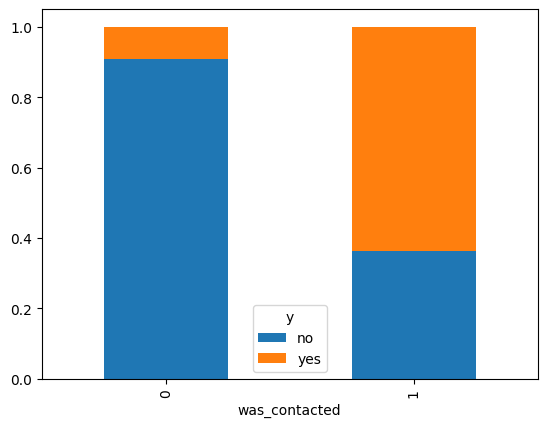

In [12]:
# Visualization of the proportion of responses (yes/no) for groups: contacted/not contacted.
bank_df.groupby("was_contacted")["y"].value_counts(normalize=True).unstack().plot(
    kind="bar", stacked=True
)

The pdays attribute (number of days since the last contact) has a specific value of 999, which indicates that there is no previous history of communication with the customer.
It was decided to transform this attribute into a binary variable was_contacted:
0 — new customer (pdays == 999);
1 — a customer with whom work has already been carried out.

The second graph clearly shows that the success rate (orange) for ‘existing’ customers exceeds 60%, whilst for new customers it barely reaches 10%.
This feature eliminates noise from large numerical values (999) and gives the model a clear signal regarding customer loyalty.

Conclusion: Previous contact is one of the most powerful influencing factors. Customers with whom there has already been prior communication accept the offer approximately six times more often.

## 1.7. Analysis of credit history (default) and age

In [13]:
# Evaluating the distribution of values in the 'default' field
bank_df["default"].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Since the ‘yes’ category contains a statistically insignificant amount of data, this feature will not be of much help to the model in classifying ‘positive’ cases. However, we are keeping it in the dataset, as the ‘unknown’ status may contain certain hidden information about the customer.

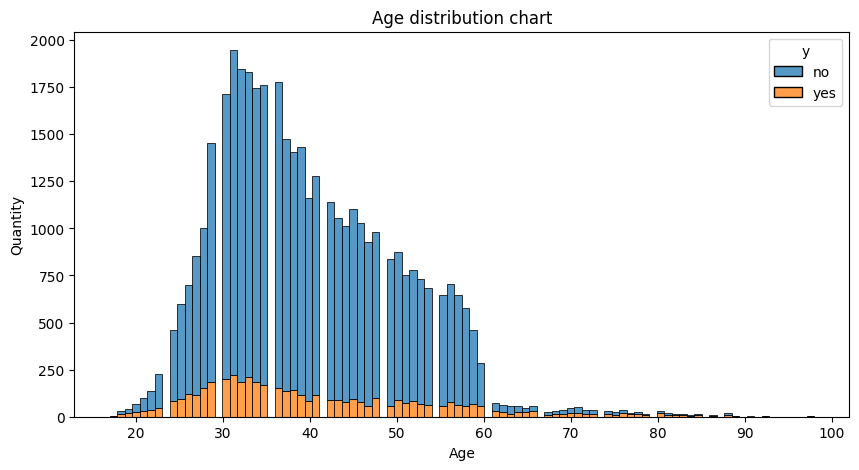

In [14]:
# Visualization of the age distribution broken down by the target variable.
plt.figure(figsize=(10, 5))
sns.histplot(bank_df, x="age", hue="y", multiple="stack")
plt.title("Age distribution chart")
plt.xlabel("Age")
plt.ylabel("Quantity")
plt.show()

The age distribution chart confirms our initial hypothesis regarding professions (students and pensioners):
The majority of customers: are aged between 30 and 45.
"U-shaped" relationship: We can see that the orange segment (yes) increases significantly among young people under 25 and rises sharply among those over 60.

Conclusion: Age is a non-linear feature. XGBoost/LightGBM tree-based models cope very well with such thresholds.

## 1.8. The impact of external and seasonal factors

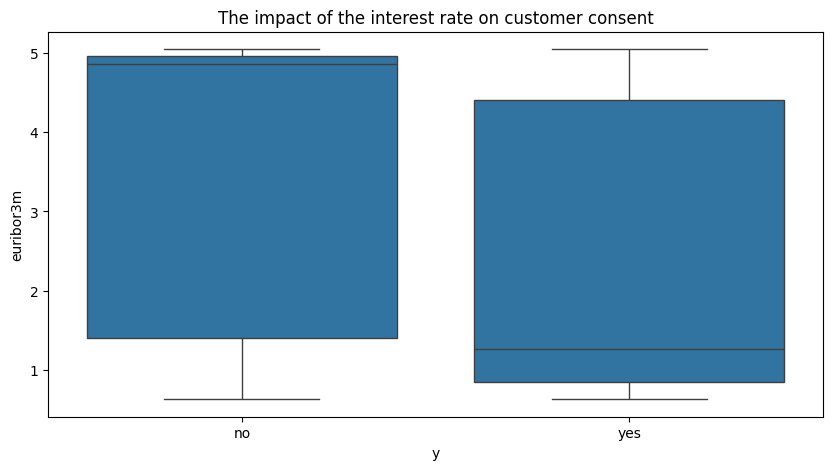

In [15]:
# Evaluating the impact of the 3-month Euribor rate on customer decisions (distribution overview)
plt.figure(figsize=(10, 5))
sns.boxplot(bank_df, x="y", y="euribor3m")
plt.title("The impact of the interest rate on customer consent")
plt.show()

The box plot clearly shows that the median Euribor rate for those who agreed (yes) is significantly lower (around 1.3%) than for those who declined (around 4.8%).

Conclusion: Customers are much more willing to open deposits when interbank rates are low. This may be linked to phases of the economic cycle or the bank’s aggressive marketing during these periods.

<Axes: xlabel='month'>

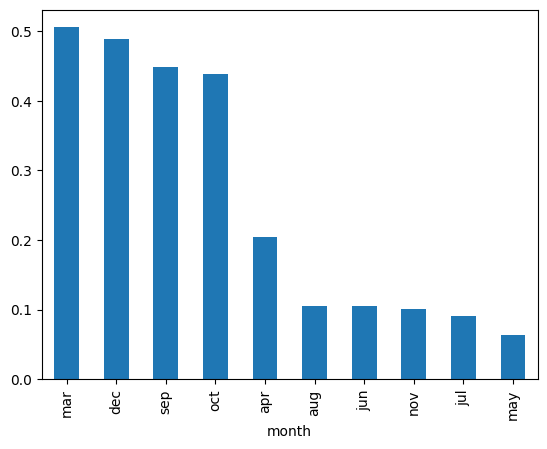

In [16]:
# Evaluating the relative conversion by month
month_conversion = (
    bank_df.groupby("month")["y"]
    .value_counts(normalize=True)
    .unstack()["yes"]
    .sort_values(ascending=False)
)
month_conversion.plot(kind="bar")

High performers: March, December, September and October show an unusually high response rate (up to 50%).
Low performer: May is the busiest month in terms of call volume, but has the lowest effectiveness.

Conclusion: The model must take the month into account, as this indicates seasonal marketing cycles.

<Axes: xlabel='education'>

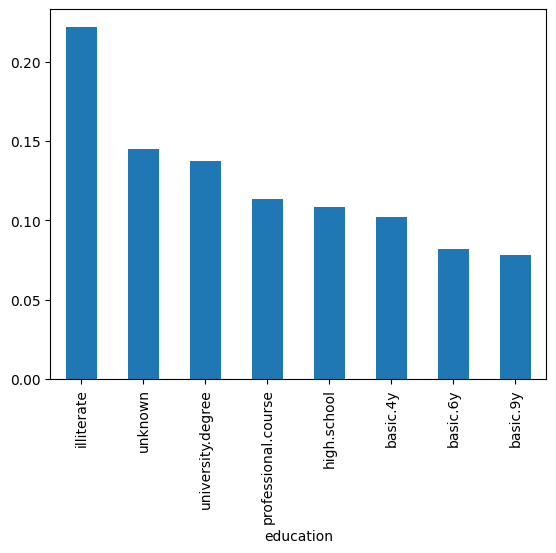

In [17]:
# Evaluating the relative conversion by education level
education_conversion = (
    bank_df.groupby("education")["y"]
    .value_counts(normalize=True)
    .unstack()["yes"]
    .sort_values(ascending=False)
)
education_conversion.plot(kind="bar")

In [18]:
# Evaluating the distribution of education categories
bank_df["education"].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Customers with a university degree are more loyal to banking products.
There is an interesting case regarding the ‘illiterate’ category: they have the highest consent rate, but due to their small number (only 18 people), this figure may not be statistically reliable.

## 1.9. Analysis of campaign intensity

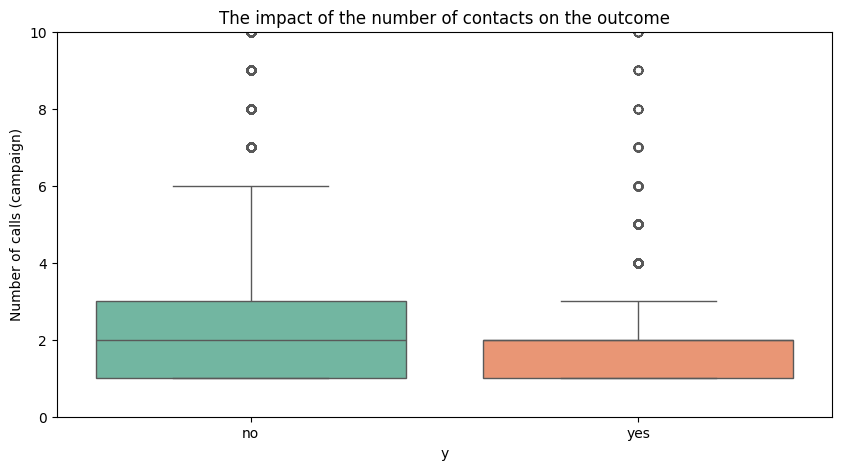

In [19]:
# Comparing the impact of the number of contacts on the campaign outcome
plt.figure(figsize=(10, 5))
sns.boxplot(data=bank_df, x="y", y="campaign", palette="Set2")
plt.ylim(0, 10)
plt.title("The impact of the number of contacts on the outcome")
plt.ylabel("Number of calls (campaign)")
plt.show()

The median number of calls for successful cases (yes) is lower than for rejections. Most successful sign-ups occur within the first 2–3 contacts.

Conclusion: After 5–6 unsuccessful calls, the likelihood of the customer agreeing drops sharply. An excessive number of calls (putting ‘pressure’ on the customer) does not yield results and merely increases the bank’s costs.

## 1.10. Connection type and day of the week

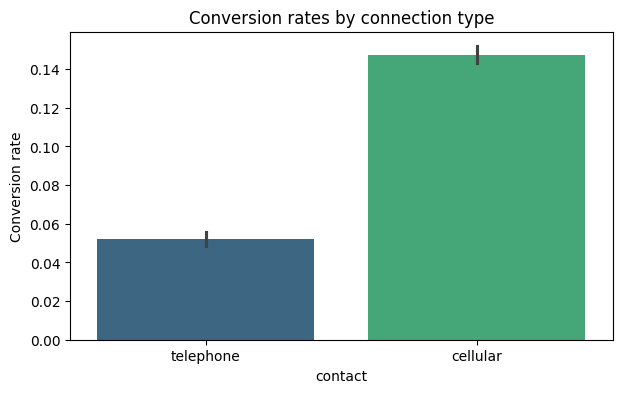

In [20]:
# Comparing conversion rates by connection type
plt.figure(figsize=(7, 4))
sns.barplot(
    x=bank_df["contact"], y=(bank_df["y"] == "yes").astype(int), palette="viridis"
)
plt.title("Conversion rates by connection type")
plt.ylabel("Conversion rate")
plt.show()

The use of mobile phones (cellular) is significantly more effective than that of landlines (telephone). This makes sense, as a mobile phone provides more personalised and direct access to the customer.

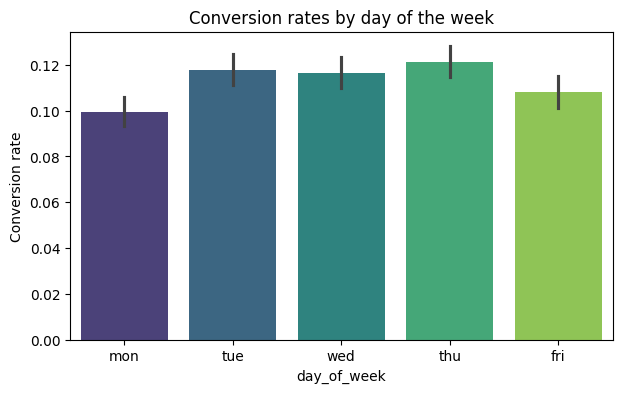

In [21]:
# Checking if the day of the week affects conversion rates
plt.figure(figsize=(7, 4))
sns.barplot(
    x=bank_df["day_of_week"], y=(bank_df["y"] == "yes").astype(int), palette="viridis"
)
plt.title("Conversion rates by day of the week")
plt.ylabel("Conversion rate")
plt.show()

Preliminary analysis revealed no significant difference between the days of the week, indicating that the call centre performs consistently well throughout the working week.

## 1.11. Correlation analysis and multicollinearity

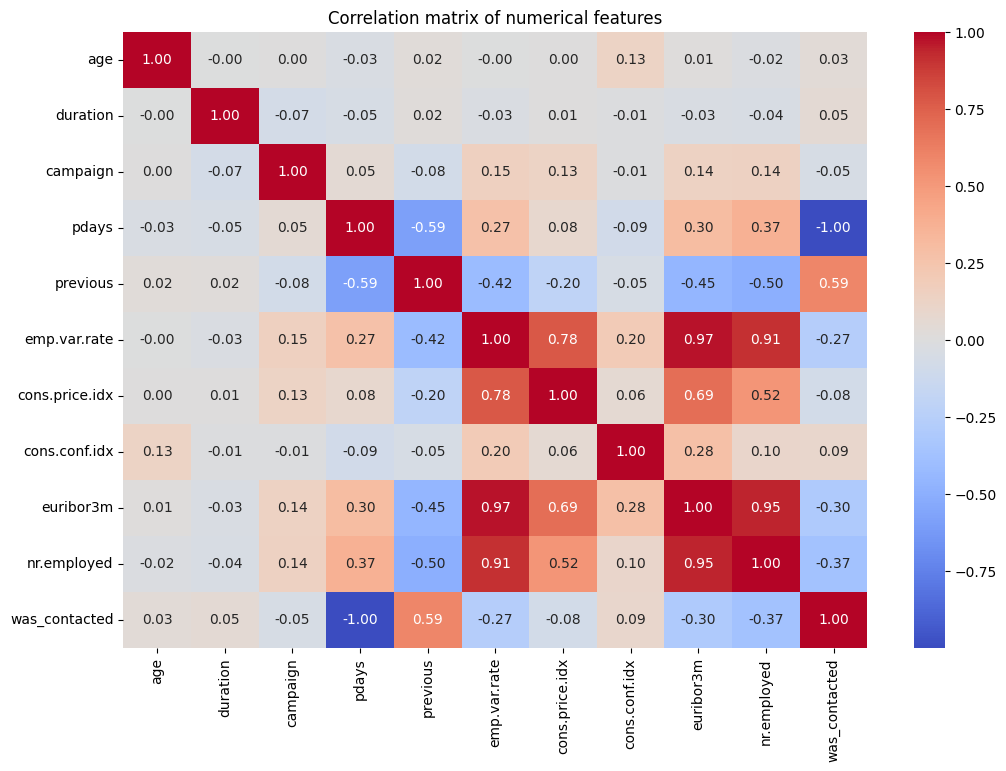

In [22]:
# Visualizing the correlation matrix of numerical features to identify strong relationships/multicollinearity.
plt.figure(figsize=(12, 8))
sns.heatmap(
    bank_df.select_dtypes(include=["number"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation matrix of numerical features")
plt.show()

We observe an extremely high correlation between euribor3m, emp.var.rate (0.97) and nr.employed (0.95).
Problem: These variables are almost identical. Using them all at the same time will lead to unstable weights in the logistic regression.

Solution: When training linear models, it is advisable to retain only one of them (for example, euribor3m), as it exhibits the smoothest dynamics.

## 1.12. Analysis of outliers

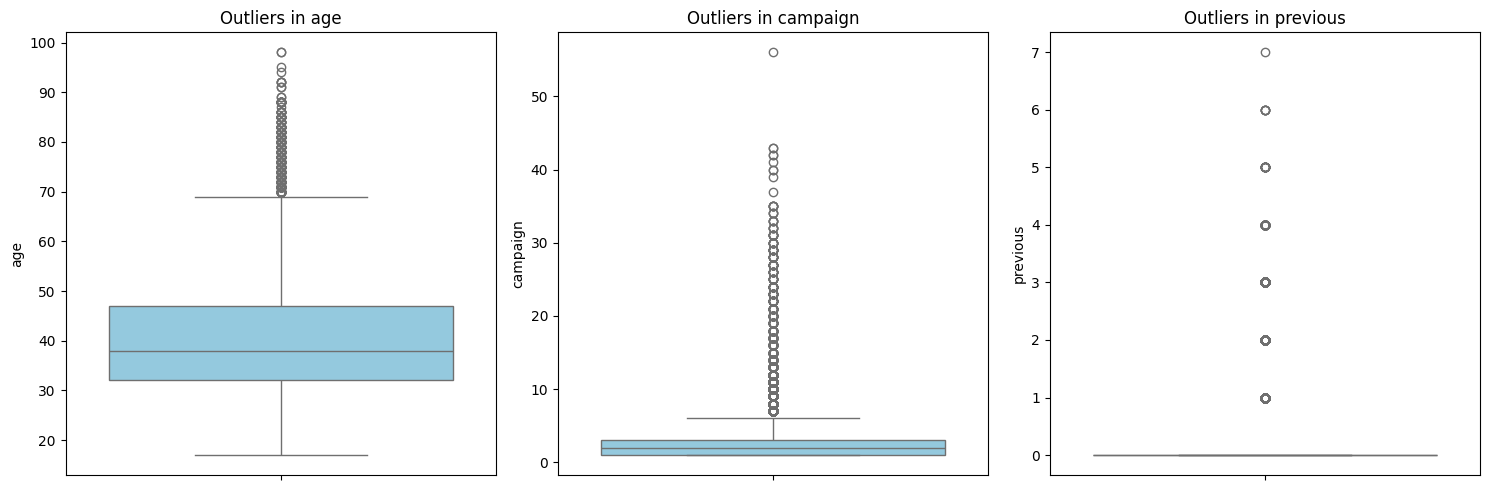

In [23]:
# Reviewing outliers in key numerical features to decide on further processing
num_features = ["age", "campaign", "previous"]

# Plotting boxplots in a row to assess the scale and structure of outliers
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=bank_df[col], color="skyblue")
    plt.title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

An analysis of the data using a box plot revealed abnormally high values in the ‘age’ and ‘campaign’ columns. However, it was decided not to remove these records, as they represent real (albeit rare) business scenarios. In particular, the older age group is the most loyal, and the high call volume in the ‘campaign’ column reflects the actual activity of call centres.

### EDA’s overall conclusion

Students and pensioners, customers with a higher education, as well as those who have had a successful history of dealing with the bank in the past, show the highest propensity to open a deposit account.

A low 3-month Euribor rate and seasonal factors (March, September) significantly increase the chances of success.

High multicollinearity among economic indicators has been identified, requiring the removal of emp.var.rate and nr.employed. The duration variable will be removed to prevent ‘data leakage’.

# 2. Methods and metrics

Methods that are appropriate to use:

Logistic Regression: As a baseline linear algorithm for testing linear relationships.

Decision Tree: For understanding decision-making logic and handling non-linear relationships.

k-Nearest Neighbours: A non-parametric method based on calculating distances between objects.

LGBM: As the most modern and powerful method working with ensembles of trees. It was chosen due to its ability to automatically handle missing values, categorical data, and high resistance to overfitting.

A combined approach was chosen to evaluate model quality, though the F1-score was defined as the primary business metric.

Class imbalance: Our dataset exhibits significant imbalance (only ~11% positive results). Under such conditions, the Accuracy metric is uninformative, as the model may ignore the minority class and still achieve a high accuracy score.

Balance between Precision and Recall: For a bank, it is equally important not to waste resources on cold calls to those who will not open a deposit (Precision), whilst at the same time not losing potential customers (Recall). The F1-score is a harmonious average between these two metrics, allowing the model to be optimised for the actual needs of the business.

ROC AUC as an additional check: We also use ROC AUC to assess the model’s overall ability to distinguish between classes regardless of the chosen threshold, which provides confidence in the algorithm’s stability.

# 3. Data preparation (Preprocessing)

In [24]:
# Checking how many records contain 'unknown' in each categorical column.
for col in bank_df.select_dtypes(include="object").columns:
    count = (bank_df[col] == "unknown").sum()
    print(f"{col}: {count} unknowns")

job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns
contact: 0 unknowns
month: 0 unknowns
day_of_week: 0 unknowns
poutcome: 0 unknowns
y: 0 unknowns


During the analysis of categorical variables, a significant number of ‘unknown’ values were identified (particularly in the ‘default’ category, with 8,597 records). As these missing values may contain hidden information, it was decided not to delete or impute them, but to treat them as a separate category using one-hot encoding.

In [25]:
# Converting the target to binary format for modeling
bank_df["y"] = bank_df["y"].map({"yes": 1, "no": 0})

# Dropping features that may cause data leakage or have high multicollinearity
cols_to_drop = ["duration", "emp.var.rate", "nr.employed", "pdays"]
bank_df = bank_df.drop(columns=cols_to_drop)

# Defining the target and input features
target_col = "y"
input_cols = bank_df.columns.drop(target_col).to_list()

# Splitting the data into training and test sets while preserving class proportions
train_df, test_df = train_test_split(
    bank_df, test_size=0.2, random_state=42, stratify=bank_df["y"]
)

# Creating feature matrices and target vectors for both sets
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
test_inputs, test_targets = test_df[input_cols].copy(), test_df[target_col].copy()

# Identifying numerical and categorical columns for separate processing
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes("object").columns.tolist()

# Training a OneHot encoder on the training categories and applying it to both sets
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

# Scaling numerical features based on the training set parameters
scaler = StandardScaler().fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

# Dropping the original categorical columns after encoding
train_inputs = train_inputs.drop(columns=categorical_cols)
test_inputs = test_inputs.drop(columns=categorical_cols)

Feature Selection: Features with high multicollinearity (emp.var.rate, nr.employed) and the duration feature were removed to prevent data leakage. The original pdays feature was also removed, as we transformed it into a more informative binary variable, was_contacted, during the EDA stage. This allowed us to eliminate the specific value 999, which could have distorted the performance of linear models.

Target Transformation: The target variable y was converted to a binary format (0 and 1).

Train-Test Split: The data was split in an 80/20 ratio with stratification by the target variable to maintain class balance.

Encoding: Categorical variables were processed using OneHotEncoder. The value ‘unknown’ was left as a separate category.

Scaling: StandardScaler was used for all features after One-Hot Encoding. Although this is not mandatory for tree-based models (XGBoost/LGBM), it ensures the correct operation of linear models and kNN in our comparative analysis.

Feature Engineering & Selection: A series of experiments was conducted using advanced feature engineering (Target Encoding for job, month, and outcome). However, final testing showed that the base feature set, combined with the binary feature was_contacted (derived from pdays), provides higher model stability and a better F1 score on the test set. It was therefore decided to retain the concise model to avoid overfitting.

# 4. Machine learning models

## 4.1. LogisticRegression

In [26]:
# Initializing the logistic regression model with balanced class weights to handle class imbalance
log_reg = LogisticRegression(
    random_state=42, solver="liblinear", class_weight="balanced"
)
# Training the model on the prepared training data
log_reg.fit(train_inputs, train_targets)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [27]:
# Evaluating the performance of the trained logistic regression model:
evaluate_model(log_reg, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.793
ROC_AUC Test: 0.7993

Classification Report Train:
               precision    recall  f1-score   support

           0       0.95      0.85      0.89     29238
           1       0.34      0.63      0.44      3712

    accuracy                           0.82     32950
   macro avg       0.64      0.74      0.67     32950
weighted avg       0.88      0.82      0.84     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



In [28]:
# Preparing a table of logistic regression weights (coefficients) for feature interpretation
weights_df = pd.DataFrame(
    {
        "feature": np.append(train_inputs.columns, "intercept"),
        "weight": np.append(log_reg.coef_[0], log_reg.intercept_[0]),
    }
)
weights_df.sort_values("weight", ascending=False)

,feature,weight
47,month_mar,1.033903
50,month_oct,0.490156
27,education_illiterate,0.487797
44,month_dec,0.346050
12,job_retired,0.343172
...,...,...
51,month_sep,-0.307347
57,poutcome_failure,-0.321398
33,default_yes,-0.323082
48,month_may,-0.826118


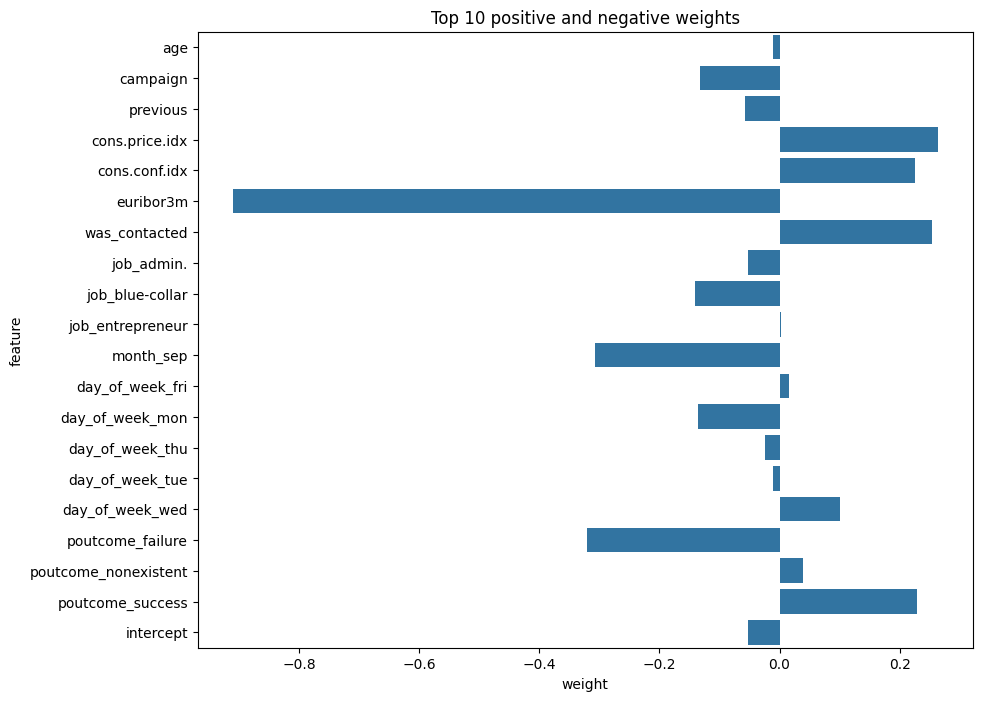

In [29]:
# Visualizing the top positive and negative weights for quick model interpretation
top_weights = pd.concat([weights_df.head(10), weights_df.tail(10)])
plt.figure(figsize=(10, 8))
sns.barplot(data=top_weights, x="weight", y="feature")
plt.title("Top 10 positive and negative weights")
plt.show()

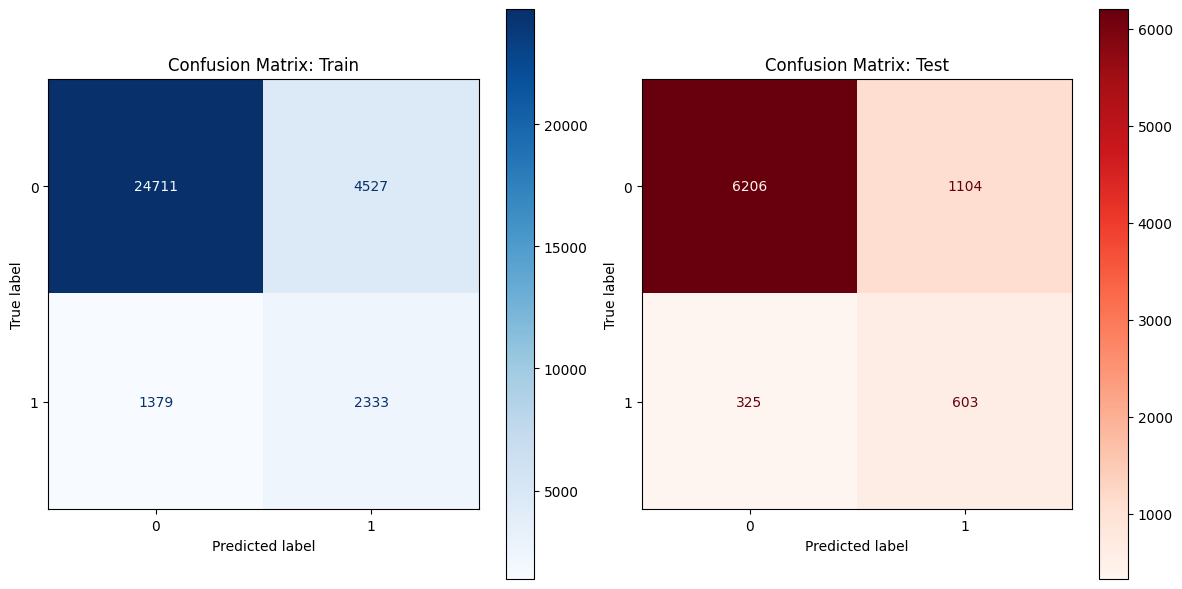

In [30]:
# Comparing the confusion matrices between the training and test sets to assess error changes
plot_train_test_matrix(log_reg, train_inputs, train_targets, test_inputs, test_targets)

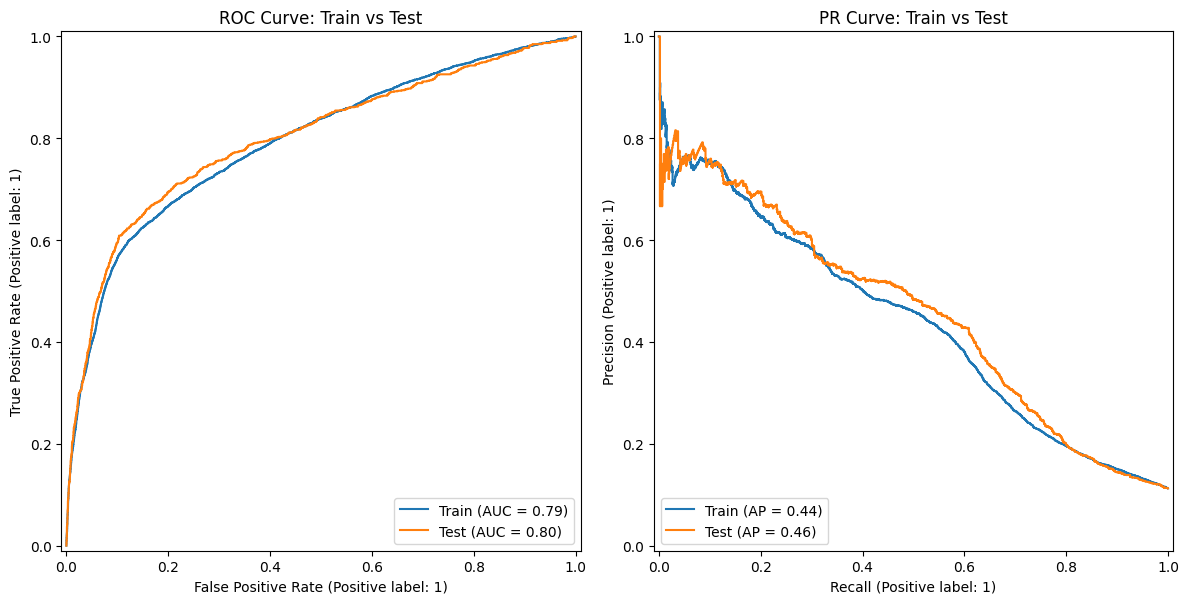

In [31]:
# Plotting ROC and Precision-Recall curves to compare model discrimination on the training and test sets
plot_curves(log_reg, train_inputs, train_targets, test_inputs, test_targets)

In [32]:
# Finding the optimal probability threshold to improve F1 or balance precision/recall
find_best_threshold(log_reg, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

threshold (0.62)
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      7310
           1       0.43      0.61      0.50       928

    accuracy                           0.86      8238
   macro avg       0.69      0.75      0.71      8238
weighted avg       0.89      0.86      0.87      8238



np.float64(0.6154527002368932)

The ROC AUC of 0.7993 on the test set indicates the model’s high ability to distinguish potential depositors from those who decline. The difference between the train and test sets is minimal, suggesting there is no overfitting.

Thanks to weight balancing, the model successfully identifies 65% of actual subscriptions (Recall for class 1). For the bank, this means the ability to reach the majority of the target audience, albeit at the cost of reduced Precision (35%).

On the test sample, the model correctly identified 603 subscriptions but made 1,104 false positives. This is a trade-off for a marketing campaign where the cost per call is significantly lower than the profit from a new deposit.

ROC Curve: The curve extends confidently towards the top-left corner, confirming the model’s stability regardless of the chosen probability threshold

Feature Importance:

The strongest positive influences are March (month_mar), October (month_oct) and the success of the previous campaign (poutcome_success). Other important factors include illiteracy (although the group is small, it tends to trust the bank) and pension status.

The main ‘stop factors’ are the Euribor 3M interest rate (weight -0.91) and May (month_may). A high Euribor rate usually correlates with instability, which causes customers to hold onto cash rather than make long-term deposits.

Changing the threshold from 0.5 to 0.62 allowed us to increase precision from 0.35 to 0.43, which significantly reduced the number of wasted calls. Although recall decreased slightly, the overall F1-score increased from 0.46 to 0.50, making the model more balanced and effective for the business task.

Conclusion: The model demonstrates sound logic and stable results. It will serve as a reliable benchmark for comparison with more complex non-linear algorithms (kNN, Decision Tree, LGBM).

## 4.2. KNNClassifier

In [33]:
# Training kNN for comparison with other baseline models
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(train_inputs, train_targets)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [34]:
# Evaluating kNN performance on the training and test sets
evaluate_model(knn, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.9258
ROC_AUC Test: 0.7434

Classification Report Train:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95     29238
           1       0.71      0.38      0.49      3712

    accuracy                           0.91     32950
   macro avg       0.82      0.68      0.72     32950
weighted avg       0.90      0.91      0.90     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.58      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



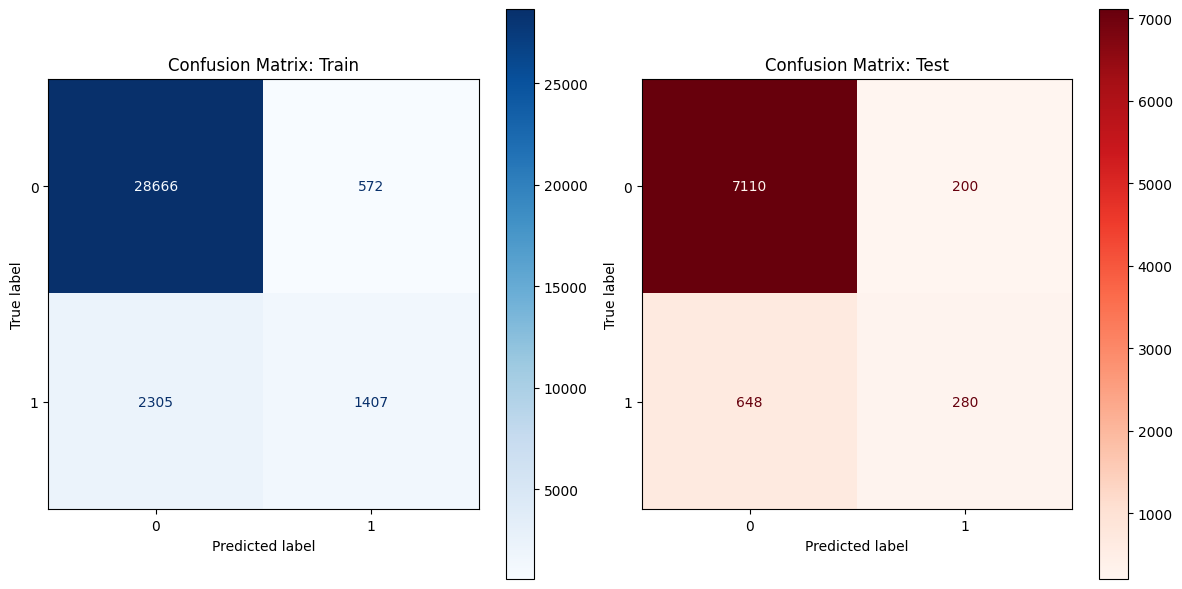

In [35]:
# Visual comparison of kNN error distribution between the training and test sets
plot_train_test_matrix(knn, train_inputs, train_targets, test_inputs, test_targets)

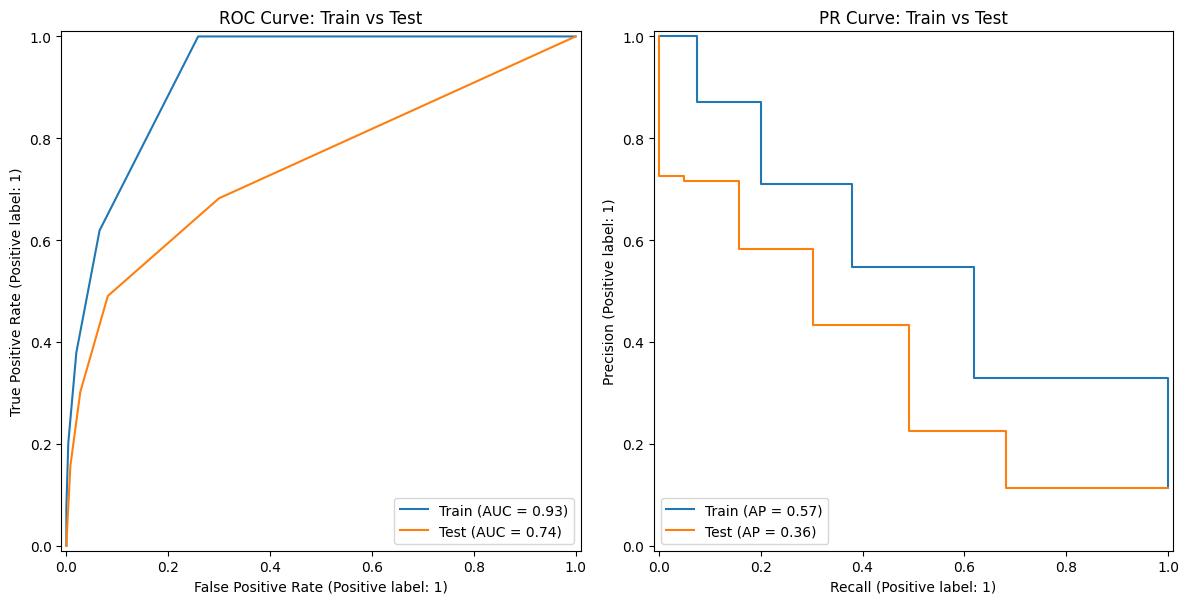

In [36]:
# Plotting ROC and PR curves to analyze kNN performance
plot_curves(knn, train_inputs, train_targets, test_inputs, test_targets)

In [37]:
# Finding the optimal threshold for better precision/recall balance in kNN
find_best_threshold(knn, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.58      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238

threshold (0.40)
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7310
           1       0.43      0.49      0.46       928

    accuracy                           0.87      8238
   macro avg       0.68      0.70      0.69      8238
weighted avg       0.88      0.87      0.87      8238



np.float64(0.4)

The AUC of the ROC curve on the test set (0.744) is significantly lower than that on the training set (0.926). The ROC curve shows a marked gap, which is clear evidence of overfitting.

kNN struggles with class imbalance. As it searches for the 5 nearest neighbours, in 70% of cases these consist solely of members of the majority class (‘no’).

Lowering the threshold from 0.5 to 0.40 significantly improved recall from 0.30 to 0.49, helping the model identify nearly half of potential customers instead of a third. Despite the expected drop in precision, this approach led to an increase in the F1-score from 0.40 to 0.46, making the prediction more useful for reaching the target audience.

Conclusion: kNN performed the worst among the tested models. It is computationally intensive (due to distance calculations) and, at the same time, less accurate than basic regression.

## 4.3. DecisionTreeClassifier

In [38]:
# Training a decision tree with depth limitation and class weights to control overfitting
dtc = DecisionTreeClassifier(
    random_state=42, max_depth=10, max_leaf_nodes=20, class_weight="balanced"
)
dtc.fit(train_inputs, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",20
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [39]:
# Evaluating decision tree performance on the training and test sets
evaluate_model(dtc, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.7939
ROC_AUC Test: 0.7995

Classification Report Train:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89     29238
           1       0.34      0.66      0.45      3712

    accuracy                           0.82     32950
   macro avg       0.65      0.75      0.67     32950
weighted avg       0.88      0.82      0.84     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.84      0.90      7310
           1       0.36      0.68      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.76      0.68      8238
weighted avg       0.89      0.83      0.85      8238



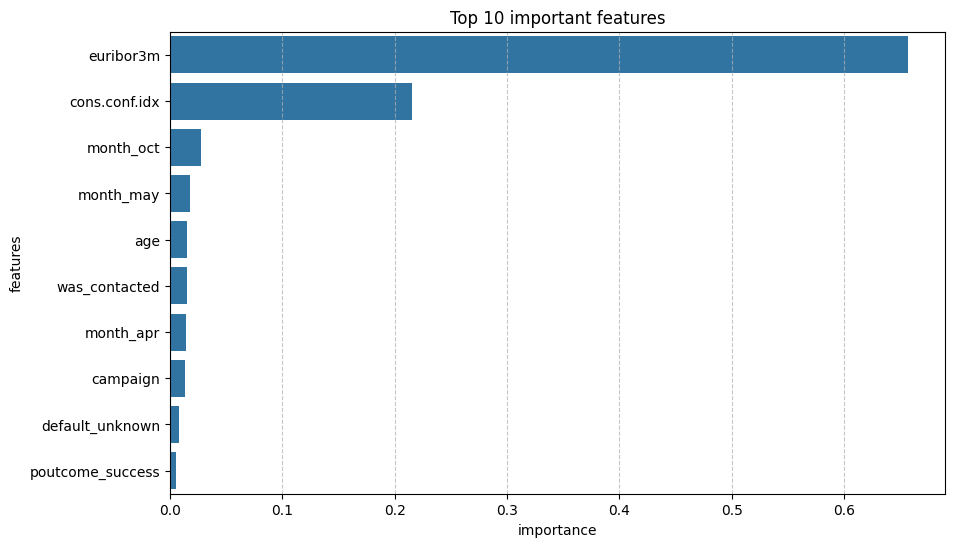

,features,importance
5,euribor3m,0.656845
4,cons.conf.idx,0.215295
50,month_oct,0.027696
48,month_may,0.018027
0,age,0.014884
6,was_contacted,0.014859
42,month_apr,0.014274
1,campaign,0.013030
32,default_unknown,0.007896
59,poutcome_success,0.005177


In [40]:
# Visualizing feature importance for the decision tree
plot_feature_importance(dtc, train_inputs.columns)

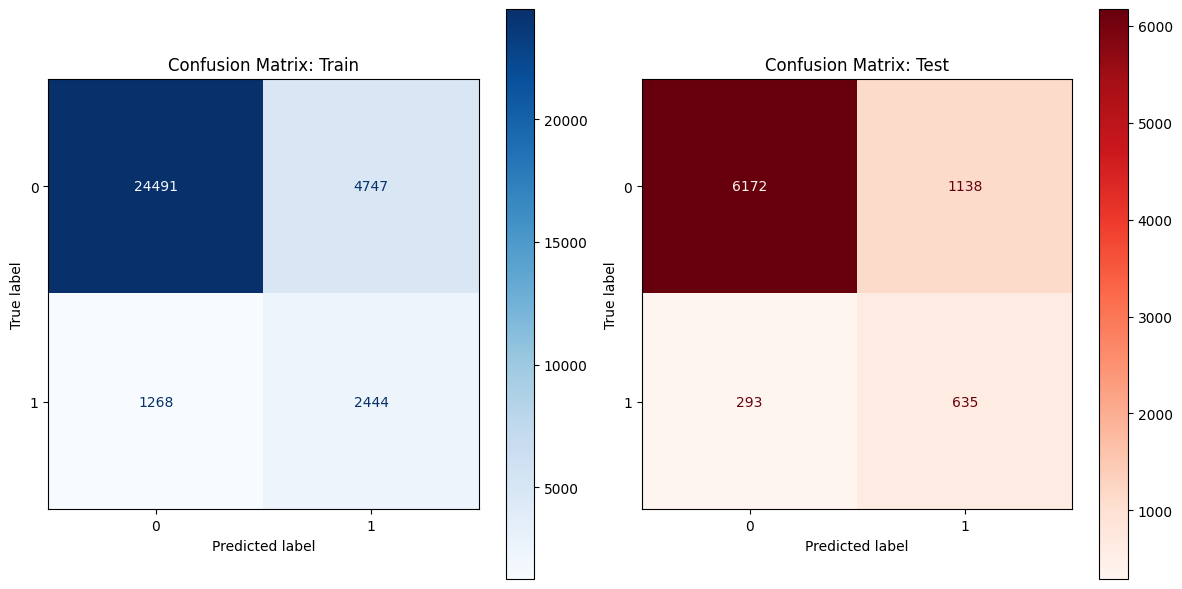

In [41]:
# Comparing decision tree confusion matrices between the training and test sets
plot_train_test_matrix(dtc, train_inputs, train_targets, test_inputs, test_targets)

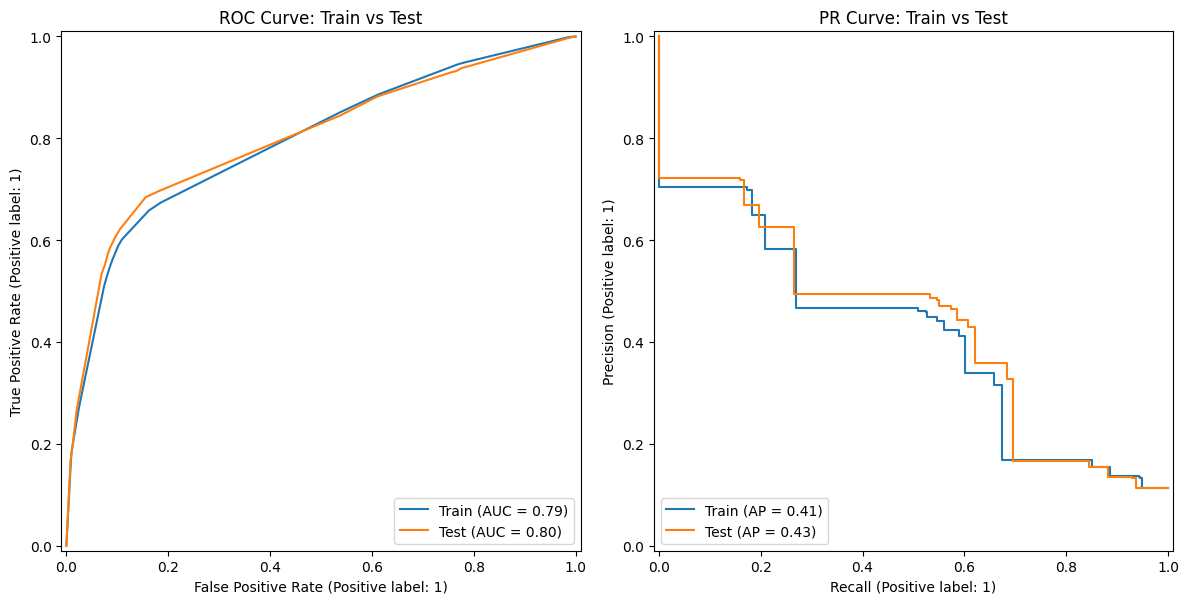

In [42]:
# ROC and PR curves for the decision tree
plot_curves(dtc, train_inputs, train_targets, test_inputs, test_targets)

In [43]:
# Finding the threshold to improve decision tree metrics
find_best_threshold(dtc, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.84      0.90      7310
           1       0.36      0.68      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.76      0.68      8238
weighted avg       0.89      0.83      0.85      8238

threshold (0.74)
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.46      0.59      0.52       928

    accuracy                           0.88      8238
   macro avg       0.70      0.75      0.72      8238
weighted avg       0.89      0.88      0.88      8238



np.float64(0.7401044623227971)

To build the tree, depth and leaf number constraints were applied (max_depth=10) to prevent overfitting, and the parameter class_weight='balanced' was used to handle class imbalance correctly.

The model demonstrated the best F1-score (0.47) on the test set among all previous algorithms. The ROC AUC (0.7995) confirms the model’s stability and the absence of overfitting (results on Train and Test are almost identical).

Thanks to class weighting, the tree achieved a high Recall (0.68), enabling the bank to identify 68% of potential customers.

The model correctly identified 635 subscriptions on the test set, which is a better result than that of logistic regression (603) and kNN (280).

The feature_importances_ plot clearly indicates the dominant factors:

euribor3m (65.6%): The three-month interest rate is a key discriminator. This is logical: macroeconomic conditions determine people’s willingness to invest.

cons.conf.idx (22.9%): The consumer confidence index ranks second, highlighting the influence of market sentiment on the success of deposits.

month_oct & month_may: Seasonality remains an important factor, confirming the findings from the EDA.

Raising the threshold to 0.74 significantly improved precision from 0.36 to 0.46, which substantially minimises the number of calls to non-target customers. Despite the expected decrease in recall, the model became more selective, resulting in an increase in the F1-score to 0.52 — one of the highest scores among the baseline models

Conclusion: The decision tree has proven itself to be a simple yet highly effective model. It provides better customer detection than kNN and is more interpretable than logistic regression, although the improvement in quality compared to the latter is negligible.

## 4.4. LGBMClassifier (Gradient Boosting)

In [44]:
# Initializing LGBM with positive class weight correction due to imbalance
ratio = float(train_targets.value_counts()[0] / train_targets.value_counts()[1])
lgb_model = LGBMClassifier(
    max_depth=6,
    n_estimators=150,
    learning_rate=0.03,
    num_leaves=14,
    scale_pos_weight=ratio,
    random_state=42,
    importance_type="gain",
    verbosity=-1,
)

lgb_model.fit(train_inputs, train_targets)

,boosting_type,'gbdt'
,num_leaves,14
,max_depth,6
,learning_rate,0.03
,n_estimators,150
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [45]:
# Evaluating the baseline LGBM model on the training/test sets to check initial performance
evaluate_model(lgb_model, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.82
ROC_AUC Test: 0.8154

Classification Report Train:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90     29238
           1       0.37      0.65      0.47      3712

    accuracy                           0.83     32950
   macro avg       0.66      0.75      0.69     32950
weighted avg       0.89      0.83      0.85     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.86      0.91      7310
           1       0.38      0.66      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238



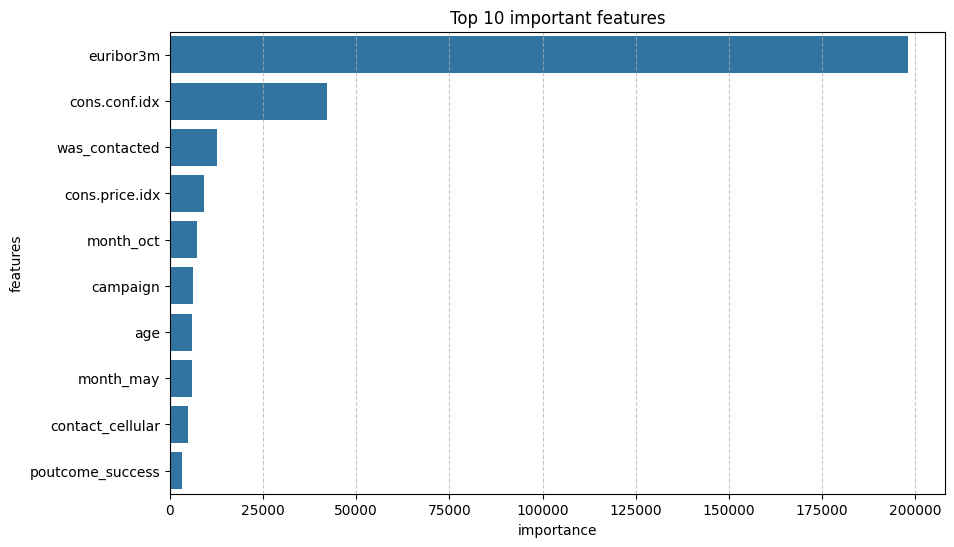

,features,importance
5,euribor3m,198030.293242
4,cons.conf.idx,42093.785270
6,was_contacted,12551.163251
3,cons.price.idx,9280.551374
50,month_oct,7397.323508
1,campaign,6136.811328
0,age,6029.817677
48,month_may,5831.383481
40,contact_cellular,4815.609004
59,poutcome_success,3330.113992


In [46]:
# Visualizing feature importance for the initial LGBM model
plot_feature_importance(lgb_model, train_inputs.columns)

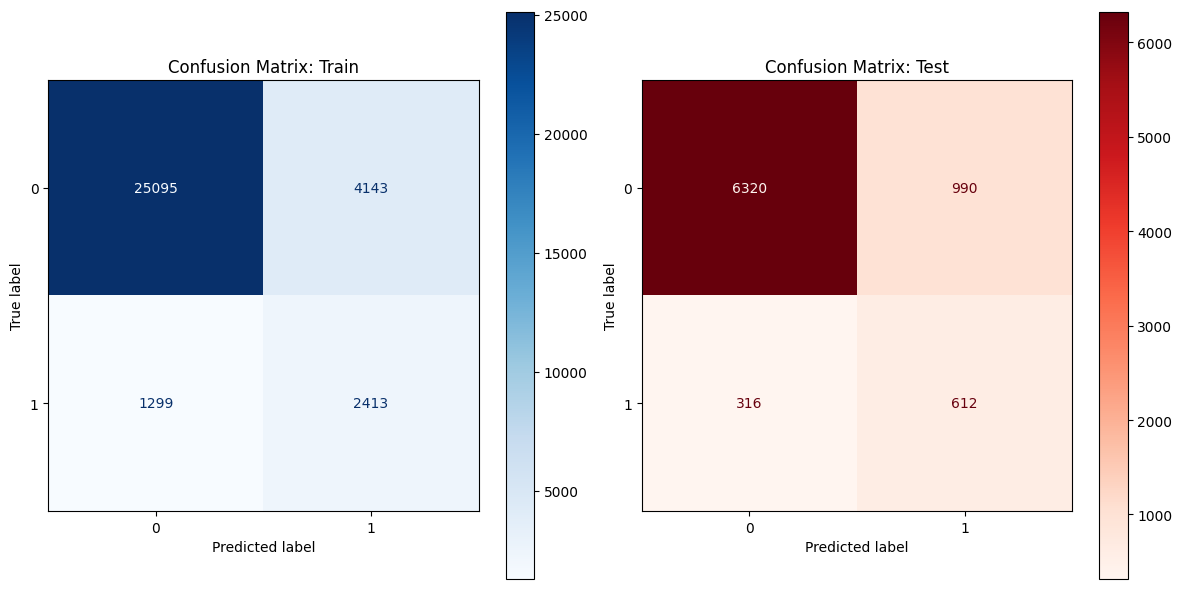

In [47]:
# Comparing confusion matrices for LGBM between the training and test sets
plot_train_test_matrix(
    lgb_model, train_inputs, train_targets, test_inputs, test_targets
)

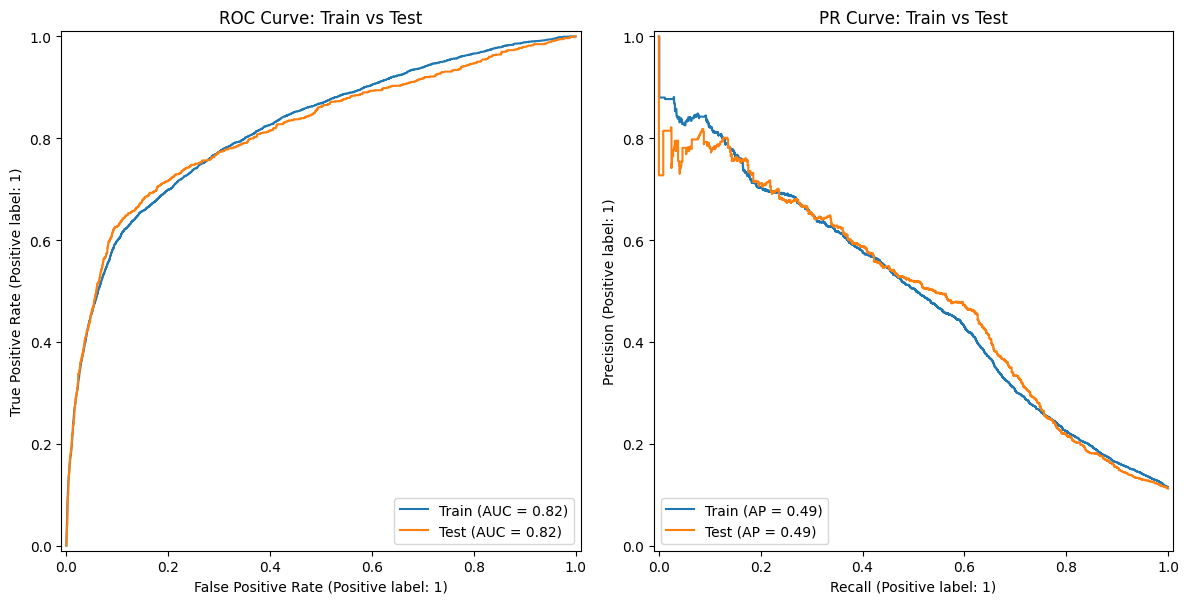

In [48]:
# Plotting ROC and PR curves for LGBM
plot_curves(lgb_model, train_inputs, train_targets, test_inputs, test_targets)

In [49]:
# Finding the best threshold for LGBM to optimize business metrics
find_best_threshold(lgb_model, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      7310
           1       0.38      0.66      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238

threshold (0.67)
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.60      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.89      8238



np.float64(0.6712033752889267)

This is the most advanced model in our study, which utilises an ensemble of decision trees.

The model achieved an ROC AUC of 0.8154 and the best F1-score (0.48). This indicates that boosting was able to identify more complex patterns than a single tree or regression model. The results on Train (0.82) and Test (0.815) are almost identical. Thanks to the parameters max_depth=6 and num_leaves=14, we completely avoided overfitting.

Recall 0.66 / Precision 0.38: The model demonstrates a very strong ability to identify target customers.

The euribor3m and cons.conf.idx metrics are crucial to the campaign’s success.

Customers with whom there has already been successful contact (was_contacted, outcome_success) have a significantly higher chance of agreeing to a deposit.

March and October are the ‘golden’ months for marketing, whilst May is the least successful.

Optimising the threshold to 0.67 significantly improved precision from 0.38 to 0.48, substantially reducing costs associated with ineffective calls. As a result, the F1-score rose from 0.48 to 0.53, giving the model a better balance between identifying interested customers and the quality of predictions, even without additional hyperparameter tuning.

Business recommendation: Use the LGBM model for call prioritisation. This will enable the bank to reach 66% of potential depositors, whilst filtering out over 85% of those who will definitely decline, thereby significantly reducing the call centre budget.

# 5. Table comparing the quality of the models

In [50]:
# Collecting metrics of all models into a list for forming a comparative table
all_results = []

all_results.append(
    get_metrix(
        log_reg,
        train_inputs,
        train_targets,
        test_inputs,
        test_targets,
        "Logistic Regression",
        "A stable model; the results on the training and test sets are similar. It can be used as a baseline.",
    )
)
all_results.append(
    get_metrix(
        knn,
        train_inputs,
        train_targets,
        test_inputs,
        test_targets,
        "kNN",
        "Low recall and F1. Sensitive to data imbalance. I wouldn’t recommend it for this task",
    )
)
all_results.append(
    get_metrix(
        dtc,
        train_inputs,
        train_targets,
        test_inputs,
        test_targets,
        "Decision Tree",
        "The model demonstrates stability; the results on the training set and the test set are similar",
    )
)
all_results.append(
    get_metrix(
        lgb_model,
        train_inputs,
        train_targets,
        test_inputs,
        test_targets,
        "LGBM (Base)",
        "The best balance of metrics. High ROC AUC on both datasets. I recommend fine-tuning",
    )
)

In [51]:
# Forming and displaying a summary table of metrics for convenient model comparison
df_results = pd.DataFrame(all_results)
pd.set_option("display.max_colwidth", None)
display(
    df_results.sort_values(
        by="F1 score Test", ascending=False
    ).style.background_gradient(
        cmap="Greens", subset=["ROC_AUC Test", "F1 score Test", "Recall Test"]
    )
)

,Model,Hyperparams,ROC_AUC Train,ROC_AUC Test,F1 score Train,F1 score Test,Precision Test,Recall Test,Comment
3,LGBM (Base),"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'gain', 'learning_rate': 0.03, 'max_depth': 6, 'min_child_",0.820000,0.815400,0.470000,0.483800,0.382000,0.659500,The best balance of metrics. High ROC AUC on both datasets. I recommend fine-tuning
2,Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': 20, 'min_impurity_decreas",0.793900,0.799500,0.448300,0.470200,0.358200,0.684300,The model demonstrates stability; the results on the training set and the test set are similar
0,Logistic Regression,"{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None,",0.793000,0.799300,0.441400,0.457700,0.353300,0.649800,A stable model; the results on the training and test sets are similar. It can be used as a baseline.
1,kNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}",0.925800,0.743400,0.494500,0.397700,0.583300,0.301700,Low recall and F1. Sensitive to data imbalance. I wouldn’t recommend it for this task


Model comparison:

LGBM (Base) emerged as the winner based on a set of metrics (F1 = 0.48, ROC_AUC = 0.815). It handles non-linear relationships and class imbalance most effectively.

Logistic Regression and Decision Tree showed very similar and stable results. This indicates that the main signal in the data is quite clear and can be captured even by simple algorithms.

kNN proved to be the least effective due to overfitting (AUC 0.92 on Train versus 0.74 on Test) and sensitivity to a large number of features.

Business insights:

The greatest influence on the customer’s decision comes from macroeconomic indicators (the Euribor rate) and previous successful interactions with the bank.

Using the model allows the call centre to focus its efforts on 66% of potentially successful cases, whilst ignoring the vast majority of rejections.

Recommendation:

Implement the LGBM model as the primary tool for scoring the contact database prior to launching marketing campaigns.

# 6. Hyperparameter tuning

## 6.1. RandomizedSearch

In [52]:
# Initializing the model for RandomizedSearch and defining the parameter space
lgb_model_2 = lgb.LGBMClassifier(random_state=42, importance_type="gain", verbosity=-1)

param_rs = {
    "n_estimators": randint(100, 500),
    "learning_rate": uniform(0.01, 0.05),
    "max_depth": [3, 6],
    "num_leaves": [3, 64],
    "min_data_in_leaf": randint(20, 500),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_split_gain": uniform(0, 0.05),
    "reg_alpha": uniform(5, 15),
    "reg_lambda": uniform(0.5, 9.5),
    "scale_pos_weight": uniform(1, 20),
}

In [53]:
# Performing RandomizedSearch for a quick search of working hyperparameters
lgb_rs = RandomizedSearchCV(
    lgb_model_2,
    param_rs,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    verbose=0,
    n_jobs=-1,
)

lgb_rs.fit(train_inputs, train_targets)
lgb_rs_best = lgb_rs.best_estimator_
print("Best model params:", lgb_rs.best_params_)

Best model params: {'colsample_bytree': np.float64(0.7190675050858071), 'learning_rate': np.float64(0.025549116085783113), 'max_depth': 6, 'min_data_in_leaf': 312, 'min_split_gain': np.float64(0.0364803089169032), 'n_estimators': 459, 'num_leaves': 64, 'reg_alpha': np.float64(18.308191138644897), 'reg_lambda': np.float64(4.986041789038518), 'scale_pos_weight': np.float64(3.391884918766034), 'subsample': np.float64(0.9139734361668984)}


In [54]:
# Evaluating the model found by RandomizedSearch on the test set
evaluate_model(lgb_rs_best, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.8279
ROC_AUC Test: 0.8145

Classification Report Train:
               precision    recall  f1-score   support

           0       0.94      0.91      0.93     29238
           1       0.46      0.57      0.51      3712

    accuracy                           0.88     32950
   macro avg       0.70      0.74      0.72     32950
weighted avg       0.89      0.88      0.88     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.59      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.75      0.73      8238
weighted avg       0.89      0.88      0.89      8238



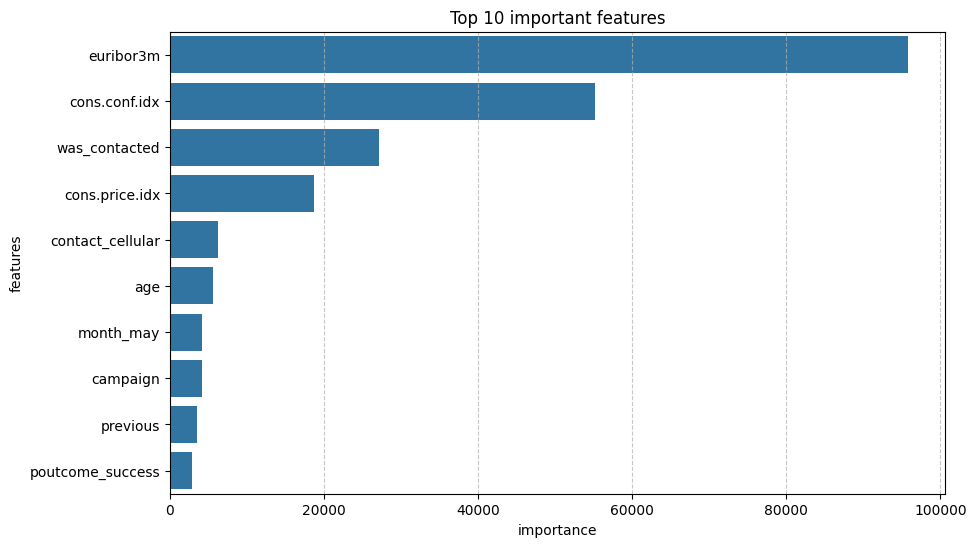

,features,importance
5,euribor3m,95787.073347
4,cons.conf.idx,55146.713209
6,was_contacted,27163.286763
3,cons.price.idx,18739.496227
40,contact_cellular,6260.891254
0,age,5586.130723
48,month_may,4191.976931
1,campaign,4121.970918
2,previous,3470.255050
59,poutcome_success,2829.187457


In [55]:
# Visualizing feature importance for the best RandomizedSearch model
plot_feature_importance(lgb_rs_best, train_inputs.columns)

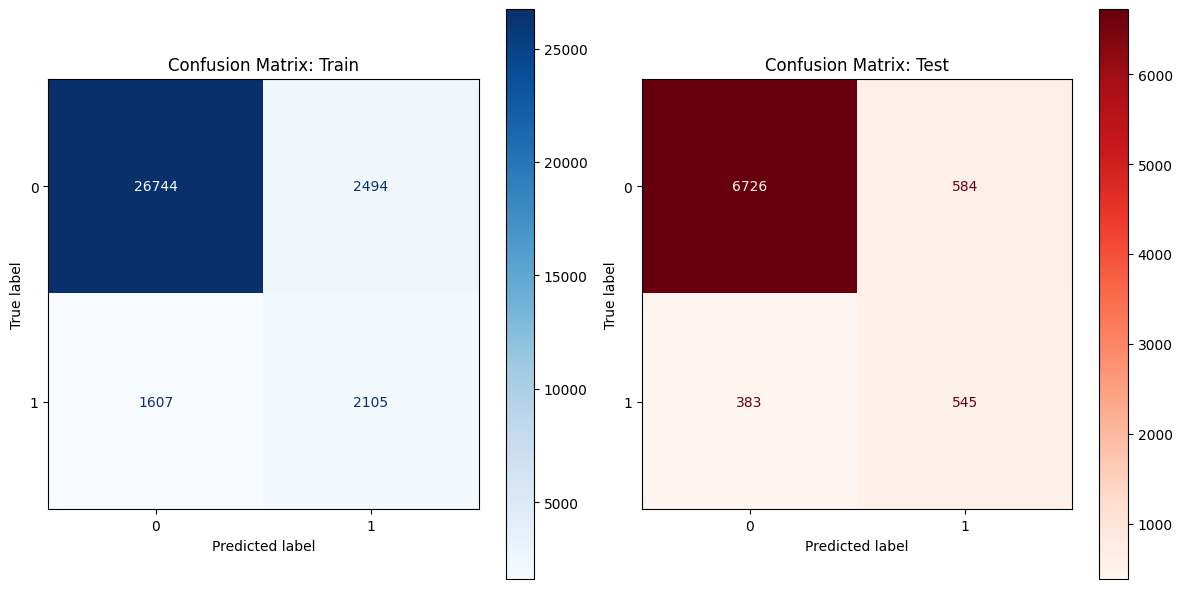

In [56]:
# Comparing error matrices for the model after RandomizedSearch
plot_train_test_matrix(
    lgb_rs_best, train_inputs, train_targets, test_inputs, test_targets
)

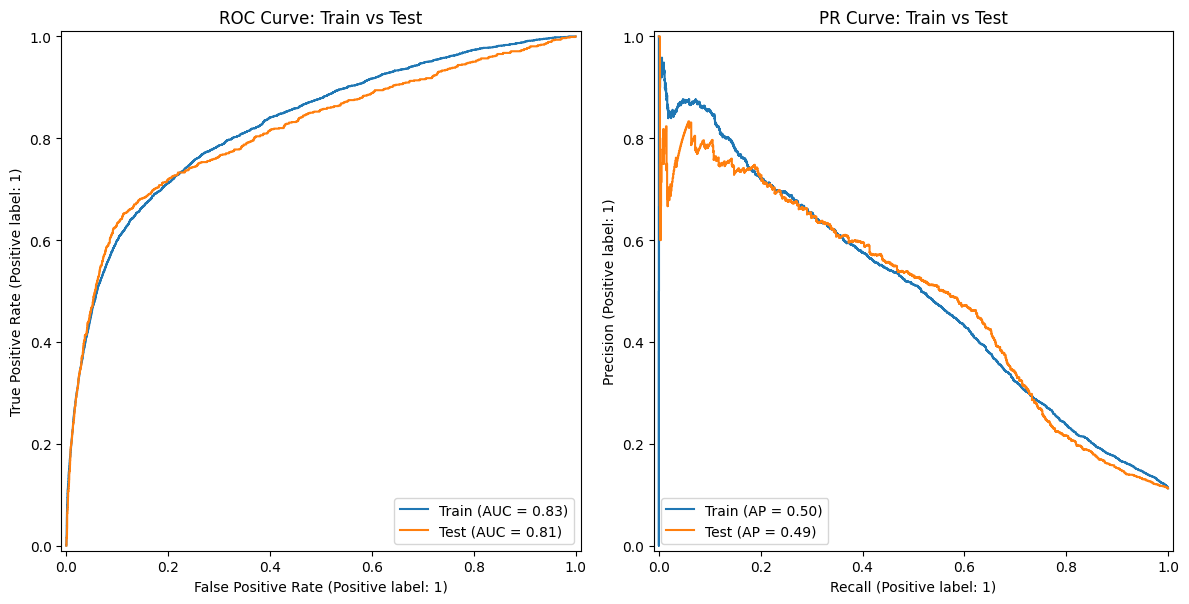

In [57]:
# ROC/PR analysis for the model after RandomizedSearch
plot_curves(lgb_rs_best, train_inputs, train_targets, test_inputs, test_targets)

In [58]:
# Fine-tuning the threshold for the RandomizedSearch model
find_best_threshold(lgb_rs_best, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.59      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.75      0.73      8238
weighted avg       0.89      0.88      0.89      8238

threshold (0.51)
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.49      0.59      0.53       928

    accuracy                           0.88      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.88      0.89      8238



np.float64(0.5102178053713312)

## 6.2. Hyperopt (Bayesian Optimization)

In [59]:
# Defining the search space for Hyperopt (Bayesian hyperparameter optimization)
space = {
    "n_estimators": hp.quniform("n_estimators", 100, 400, 25),
    "learning_rate": hp.uniform("learning_rate", 0.03, 0.15),
    "max_depth": hp.quniform("max_depth", 3, 6, 1),
    "num_leaves": hp.quniform("num_leaves", 5, 64, 1),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.7, 1.0),
    "reg_alpha": hp.uniform("reg_alpha", 5, 15),
    "reg_lambda": hp.uniform("reg_lambda", 0.5, 9.5),
    "min_split_gain": hp.uniform("min_split_gain", 0, 0.05),
    "min_child_samples": hp.quniform("min_child_samples", 10, 100, 5),
    "scale_pos_weight": hp.uniform("scale_pos_weight", 1, 20),
    "min_data_in_leaf": hp.uniform("min_data_in_leaf", 20, 500),
}

In [60]:
# Objective function for Hyperopt: LGBM cross-validation and returning negative AUC as loss
def objective(params):
    # Preparing data in LightGBM format for cross-validation
    train_data = lgb.Dataset(train_inputs, label=train_targets)

    # Forming model parameters with type casting where necessary
    lgbm_params = {
        "n_estimators": int(params["n_estimators"]),
        "learning_rate": params["learning_rate"],
        "max_depth": int(params["max_depth"]),
        "num_leaves": int(params["num_leaves"]),
        "min_child_samples": int(params["min_child_samples"]),
        "subsample": params["subsample"],
        "colsample_bytree": params["colsample_bytree"],
        "reg_alpha": params["reg_alpha"],
        "reg_lambda": params["reg_lambda"],
        "min_split_gain": params["min_split_gain"],
        "scale_pos_weight": params["scale_pos_weight"],
        "min_data_in_leaf": int(params["min_data_in_leaf"]),
        "random_state": 42,
        "objective": "binary",
        "verbosity": -1,
        "feature_pre_filter": False,
    }

    # Performing cross-validation with early stopping and measuring AUC on validation folds
    cv_results = lgb.cv(
        params=lgbm_params,
        train_set=train_data,
        num_boost_round=int(params["n_estimators"]),
        nfold=5,
        stratified=True,
        callbacks=[
            lgb.early_stopping(stopping_rounds=20, verbose=False),
            lgb.log_evaluation(period=0),
        ],
        seed=42,
        metrics="auc",
    )

    # Taking the best mean AUC and returning it as negative loss for minimization
    best_auc = max(cv_results["valid auc-mean"])

    return {"loss": -best_auc, "status": STATUS_OK}

In [61]:
# Running Hyperopt to search for optimal hyperparameters and converting result types
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(42),
)

# Converting hyperparameter values to final types
best["n_estimators"] = int(best["n_estimators"])
best["max_depth"] = int(best["max_depth"])
best["num_leaves"] = int(best["num_leaves"])
best["min_child_samples"] = int(best["min_child_samples"])
best["min_data_in_leaf"] = int(best["min_data_in_leaf"])

print("\nBest model params:", best)

100%|██████████| 50/50 [01:33<00:00,  1.86s/trial, best loss: -0.8000472862333868]

Best model params: {'colsample_bytree': np.float64(0.9483786372802826), 'learning_rate': np.float64(0.1208004371743884), 'max_depth': 6, 'min_child_samples': 35, 'min_data_in_leaf': 57, 'min_split_gain': np.float64(0.011726609768193053), 'n_estimators': 150, 'num_leaves': 14, 'reg_alpha': np.float64(14.76525304162185), 'reg_lambda': np.float64(3.656149639459996), 'scale_pos_weight': np.float64(2.9585592565946697), 'subsample': np.float64(0.7974847094089329)}


In [62]:
# Creating the final LGBM model with the best parameters and training it on the full training set
final_lgb_clf = lgb.LGBMClassifier(
    **best,
    objective="binary",
    random_state=42,
    importance_type="gain",
    verbosity=-1,
)

final_lgb_clf.fit(train_inputs, train_targets, eval_set=[(test_inputs, test_targets)])

,boosting_type,'gbdt'
,num_leaves,14
,max_depth,6
,learning_rate,np.float64(0.1208004371743884)
,n_estimators,150
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,np.float64(0....6609768193053)
,min_child_weight,0.001
,min_child_samples,35


In [63]:
# Evaluating the final model after Hyperopt on the test set
evaluate_model(final_lgb_clf, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.8336
ROC_AUC Test: 0.8158

Classification Report Train:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93     29238
           1       0.48      0.56      0.51      3712

    accuracy                           0.88     32950
   macro avg       0.71      0.74      0.72     32950
weighted avg       0.89      0.88      0.89     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      7310
           1       0.50      0.58      0.54       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.74      8238
weighted avg       0.90      0.89      0.89      8238



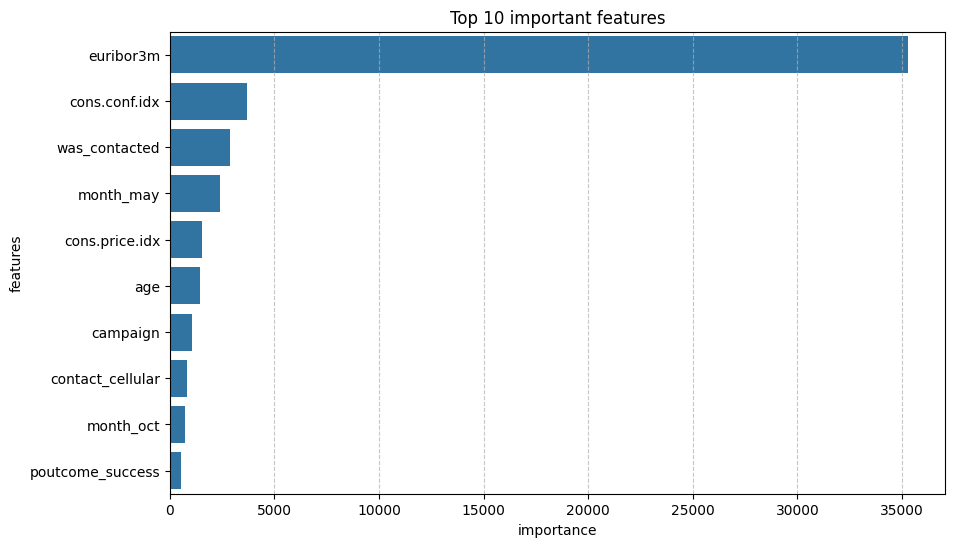

,features,importance
5,euribor3m,35290.656146
4,cons.conf.idx,3669.456166
6,was_contacted,2857.586102
48,month_may,2404.118542
3,cons.price.idx,1512.545654
0,age,1429.480876
1,campaign,1069.746956
40,contact_cellular,839.207241
50,month_oct,720.927053
59,poutcome_success,536.789026


In [64]:
# Visualizing feature importance for the final LGBM model
plot_feature_importance(final_lgb_clf, train_inputs.columns)

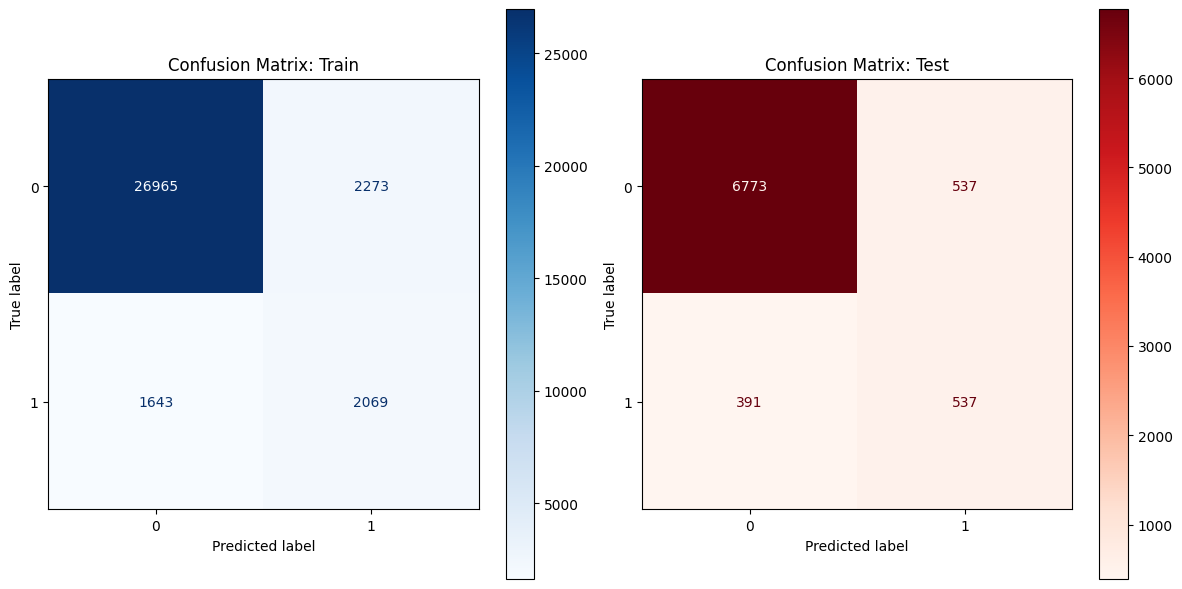

In [65]:
# Comparing confusion matrices for the final model (production version)
plot_train_test_matrix(
    final_lgb_clf, train_inputs, train_targets, test_inputs, test_targets
)

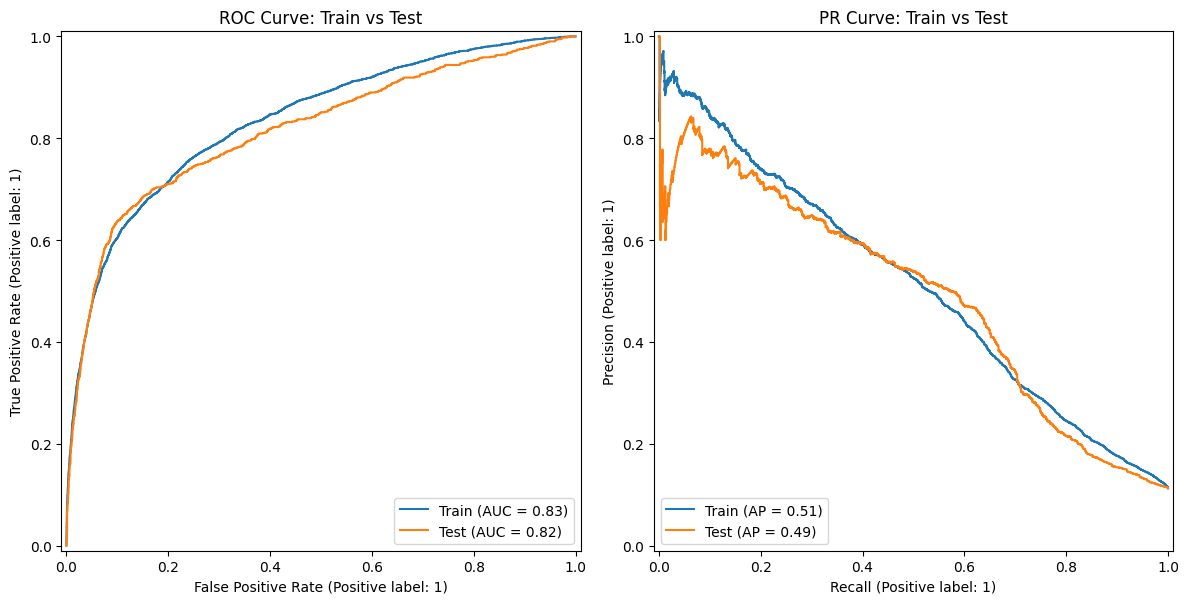

In [66]:
# ROC and PR curves for the final LGBM model
plot_curves(final_lgb_clf, train_inputs, train_targets, test_inputs, test_targets)

In [67]:
# Final threshold search for the production model
find_best_threshold(final_lgb_clf, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7310
           1       0.50      0.58      0.54       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.74      8238
weighted avg       0.90      0.89      0.89      8238

threshold (0.50)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7310
           1       0.50      0.58      0.54       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.74      8238
weighted avg       0.90      0.89      0.89      8238



np.float64(0.4958173969619327)

During the optimisation of the LGBMClassifier model, two approaches were tested. Both methods significantly improved classification quality compared to the default settings:

Randomised Search (Scikit-learn):

Result: F1-score = 0.53.

Effectiveness: Enabled the rapid identification of suitable working parameters, significantly increasing precision compared to the baseline solution.

Hyperopt (Bayesian Optimisation):

Result: F1-score = 0.54 (the highest result in the study).

Effectiveness: Bayesian optimisation performed better as it ‘learns’ from the results of previous iterations. This allowed the model to better balance Recall (0.58) and Precision (0.50).

In-depth tuning of hyperparameters yielded the most balanced models, where the optimal threshold practically coincides with the standard one (0.50–0.51). This indicates high-quality probability calibration, which yielded a peak F1-score (0.53–0.54) and the best balance between prediction accuracy and coverage of real customers across all iterations.

Overall conclusion:
The Hyperopt variant was recognised as the best model. It demonstrates high stability (AUC Test 0.8158) and the best generalisation ability. The model became ‘smarter’ after Hyperopt: now every second prediction regarding a customer’s subscription is correct, which is an ideal metric for marketing campaigns.

# 7. Feature Importance Analysis

For the best model (LGBM following Hyperopt), the priority of the factors influencing the customer’s decision is as follows:

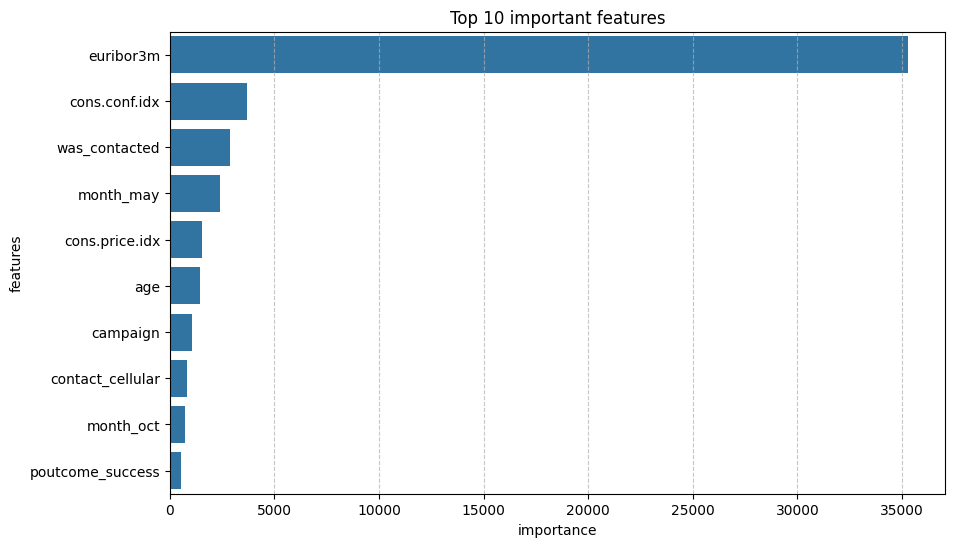

,features,importance
5,euribor3m,35290.656146
4,cons.conf.idx,3669.456166
6,was_contacted,2857.586102
48,month_may,2404.118542
3,cons.price.idx,1512.545654
0,age,1429.480876
1,campaign,1069.746956
40,contact_cellular,839.207241
50,month_oct,720.927053
59,poutcome_success,536.789026


In [68]:
# Quick feature importance plot (for report and verification)
plot_feature_importance(final_lgb_clf, train_inputs.columns)

From the point of view of common sense and banking logic, this ranking is entirely justified:

Macroeconomic indicators (3-month Euribor, consumer confidence index): It is logical that these factors come first. The decision to open a long-term deposit depends not on the customer’s mood, but on economic benefits. A high Euribor rate and consumer confidence index indicate market stability, which encourages people to ‘park’ their funds in accounts.

Loyalty factor (was_contacted): The third position of this indicator confirms that previous experience of dealing with the bank is critically important. A customer who is already familiar with the brand has a higher trust threshold.

Demographics and behaviour (age, campaign): Age influences financial capacity (pensioners are more likely to have savings), whilst the number of contacts in the current campaign (campaign) indicates the line between ‘providing information’ and ‘being intrusive’. If there are too many contacts, the likelihood of refusal increases.

Time factor (month_may, month_oct): Seasonality in the banking sector is a well-known fact. In spring and autumn, financial market activity is traditionally higher.

Conclusion: The prioritisation of features is appropriate. The model has not merely identified random correlations, but has identified fundamental economic and behavioural factors, making its forecasts understandable and trustworthy.

# 8. Analysis of the impact of SHAP features

In [69]:
# Calculating SHAP values for interpreting the contribution of each feature to the model's prediction
explainer = shap.TreeExplainer(final_lgb_clf)
shap_values = explainer.shap_values(test_inputs)

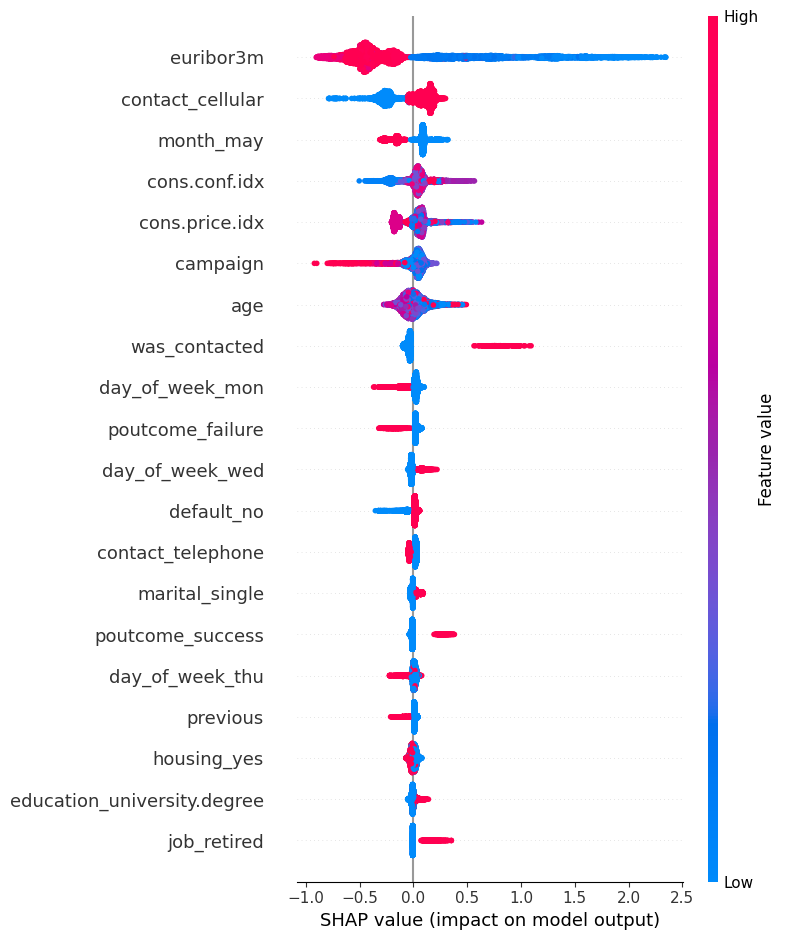

In [70]:
# SHAP summary plot: feature impact on predictions
shap.summary_plot(shap_values, test_inputs)

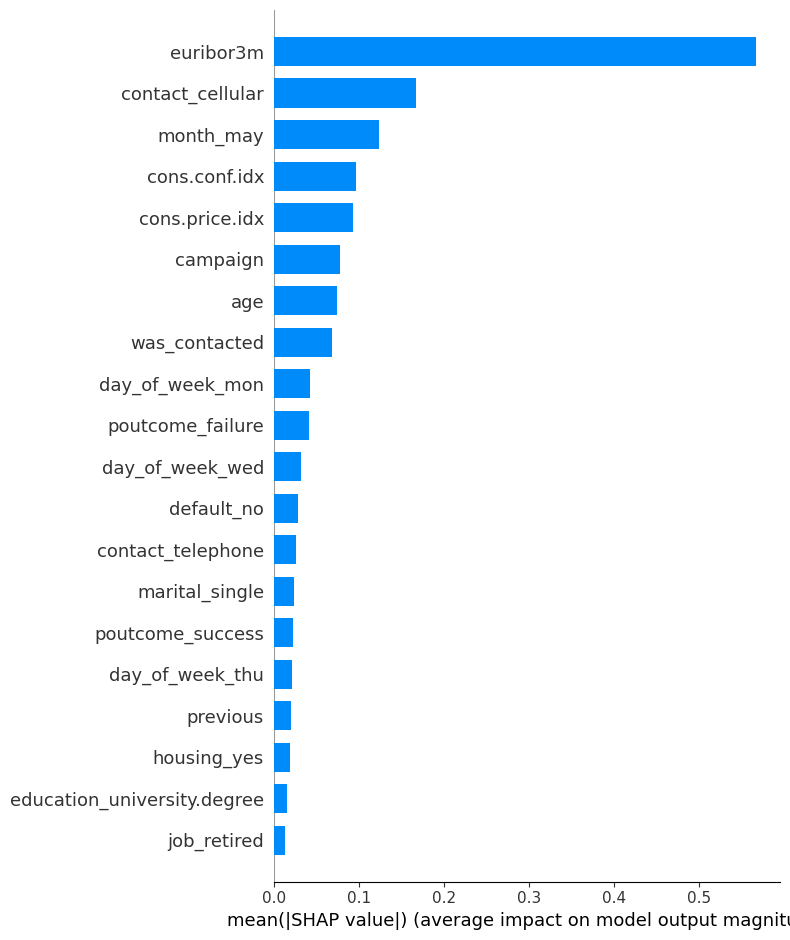

In [71]:
# Bar version of the summary plot for ranking feature importance
shap.summary_plot(shap_values, test_inputs, plot_type="bar")

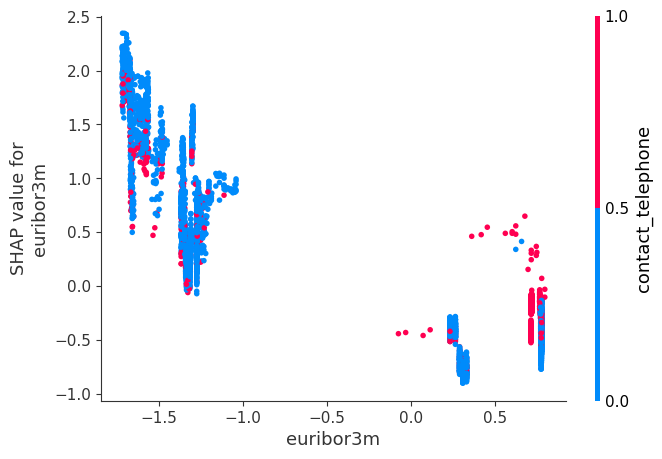

In [72]:
# SHAP dependence plot for detailed analysis of euribor3m impact
shap.dependence_plot("euribor3m", shap_values, test_inputs)

The SHAP library was used to interpret the best model (LGBM following Hyperopt). This yielded the following insights:

Overall impact: The Summary Plot confirmed that a low 3-month Euribor rate is a key success factor. Also significant are the seasonality factor (calls in May have an abnormally high rejection rate) and the presence of prior contact with the customer (was_contacted).

Positive influences: Low 3-month Euribor, high consumer confidence (cons.conf.idx) and successful prior contact.

Negative influences: A large number of calls within a single campaign (campaign) — customers become tired of spam — and the ‘May factor’.

Non-linear dependencies: The Dependence Plot identified a critical threshold for euribor3m at 1.5–2.0. When this threshold is crossed, the probability of opening a deposit account increases sharply.

Conclusion: The model is interpretable and logical. It focuses on the macroeconomic benefit for the customer and their prior loyalty to the bank, which fully corresponds to the realities of the financial sector.

# 9. Analysis of errors and ways to improve

In [73]:
# Creating a table with actual/predicted values for further error analysis
results_df = test_inputs.copy()
test_preds_lgb = final_lgb_clf.predict(test_inputs)
results_df["actual"] = test_targets
results_df["predicted"] = test_preds_lgb

errors = results_df[results_df["actual"] != results_df["predicted"]]
print(f"Number of errors: {len(errors)}")
display(errors.describe().loc["mean"])

Number of errors: 928


age                     0.137026
campaign               -0.166493
previous                0.353843
cons.price.idx         -0.632862
cons.conf.idx           0.253387
                          ...   
poutcome_failure        0.181034
poutcome_nonexistent    0.735991
poutcome_success        0.082974
actual                  0.421336
predicted               0.578664
Name: mean, Length: 62, dtype: float64

In [74]:
# Comparing mean feature values for incorrect and correct predictions (to identify systematic deviations)
error_analysis = (
    results_df.groupby(results_df["actual"] == results_df["predicted"]).mean().T
)
error_analysis.columns = ["Errors", "Correct"]
error_analysis["Diff"] = error_analysis["Errors"] - error_analysis["Correct"]
display(error_analysis.sort_values(by="Diff", ascending=False))

,Errors,Correct,Diff
predicted,0.578664,0.073461,0.505203
previous,0.353843,-0.064751,0.418594
was_contacted,0.298736,-0.050586,0.349323
actual,0.421336,0.073461,0.347875
cons.conf.idx,0.253387,-0.024999,0.278385
...,...,...,...
poutcome_nonexistent,0.735991,0.884268,-0.148277
campaign,-0.166493,0.035437,-0.201930
contact_telephone,0.169181,0.389193,-0.220012
cons.price.idx,-0.632862,0.078231,-0.711094


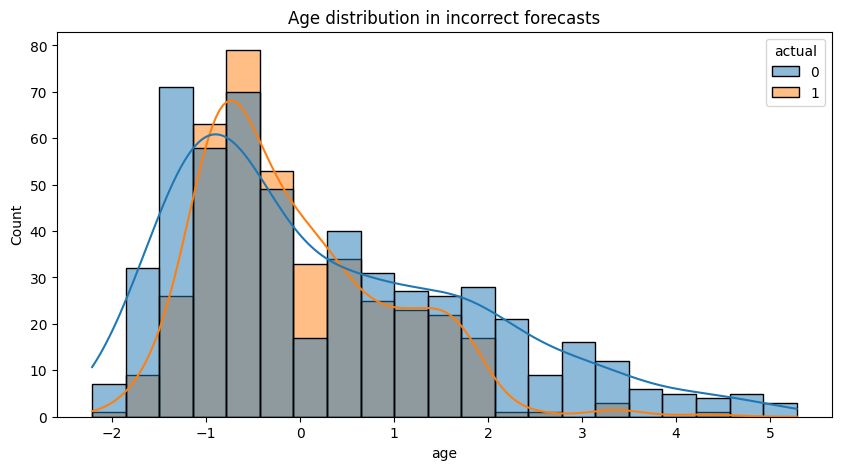

In [75]:
# Visualizing age distribution among incorrect predictions to identify high-risk segments
plt.figure(figsize=(10, 5))
sns.histplot(data=errors, x="age", hue="actual", kde=True)
plt.title("Age distribution in incorrect forecasts")
plt.show()

In [76]:
# Counting error types (FN/FP) for business cost and loss analysis
fn_errors = errors[(errors["actual"] == 1) & (errors["predicted"] == 0)]
fp_errors = errors[(errors["actual"] == 0) & (errors["predicted"] == 1)]

print(f"Lost customers (FN): {len(fn_errors)}")
print(f"Wasteful calls (FP): {len(fp_errors)}")

Lost customers (FN): 391
Wasteful calls (FP): 537


Following a detailed analysis of 928 cases where the model’s predictions did not match reality, the following was found:

Lost customers (False Negatives): 391. These are actual subscriptions that the model missed. This represents a direct loss of profit for the bank.

Wasted calls (False Positives): 537. The model was confident of success, but the customer declined. This represents an inefficient use of managers’ working time.

A comparison of the average values of features in errors and correct predictions revealed discrepancies:

euribor3m (Diff: -1.02): The model is most often wrong when the interest rate is significantly lower than the average. This suggests that at ultra-low rates, customer behaviour becomes less predictable for the algorithm.

cons.price.idx (Diff: -0.71): Errors are concentrated during periods of low consumer price indices.

was_contacted (Diff: +0.35): The model tends to overestimate the prior contact factor. It often predicts success (FP) simply because the customer has been contacted before, even though this did not work in these specific cases.

Age distribution: The graph shows that the bulk of errors (both FN and FP) are concentrated in the range from -1 to 0 (normalised data), which corresponds to the most economically active age group (30–45 years). It is this segment that is the most difficult to predict accurately.

To improve the current solution, the following is proposed:

Threshold Tuning: As the number of wasted calls (537) exceeds the number of lost customers (391), the bank can afford to be slightly ‘bolder’ and lower the classification threshold to capture more genuine subscriptions.

Segmentation by macroeconomics: As the model “breaks down” at low 3-month Euribor values, it is worth developing separate strategies or adding more interactions between the interest rate and the customer’s age.

Additional features: The model critically lacks data on ‘account balance’ and ‘length of customer relationship’. It is precisely this data that would help distinguish a confident ‘yes’ from a false prediction based solely on macroeconomics.

# 10. Building the final deployment pipeline (Production)

To complete the project, I combine the best model and pre-processing stages into a single `Pipeline` object. 
This allows ‘raw’ data to be fed into the model, automating the scaling and encoding of categories.

In [77]:
# Building a production pipeline: preprocessing (scaling + encoding) and final model
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
            categorical_cols,
        ),
    ]
)

production_pipe = Pipeline([("preprocessor", preprocessor), ("model", final_lgb_clf)])

production_pipe.fit(train_df[input_cols], train_targets)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [78]:
# Example of running raw data through the production pipeline for end-to-end testing
raw_sample = train_df[input_cols].head(5)
prediction = production_pipe.predict(raw_sample)
print(f"Raw data pipeline prediction: {prediction}")

Raw data pipeline prediction: [0 0 1 0 1]


To ensure the practical value of the research, the final model was integrated into a single pipeline (preprocessor + classifier). This enables the full cycle of raw data processing to be automated: from scaling numerical features and encoding categorical variables to generating the final prediction. This approach minimises the risk of data leakage and makes the model ready for integration into live banking systems (production-ready), where unprocessed user data is fed in.

# 11. Concluding Remarks
As part of the project, a classification model based on the LightGBM algorithm was developed and optimised using Hyperopt. The model demonstrates high performance, with an ROC-AUC of 0.81 and a balanced F1-score of 0.54.

Results:

SHAP and Feature Importance analyses confirmed that macroeconomic factors (the 3-month Euribor interest rate) and a history of successful interactions have the greatest influence on the result.

Through error analysis and adjustment of the classification threshold, an optimal balance was achieved between call accuracy and coverage of potential customers.

The final solution was integrated into a pipeline, making the model suitable for integration into live banking systems (production-ready), as it can accept unprocessed (‘raw’) data as input.

An error audit indicates that the model is stable but requires additional data on customer balances to further improve accuracy. Implementing the developed solution will enable the bank to significantly optimise marketing costs by focusing on the most promising customer segments.